In [16]:
# procrustes with precomputed CLIP embeddings, with retrieval and gap metrics

import sys
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader    
sys.path.append(os.path.abspath(".."))
from analysis.viz import visualize_3d, tsne_3d
from analysis.modality_gap import compute_gap
from metrics.retrieval import retrieval

import procrustes
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, random_split

import torch.nn.functional as F

# Add parent directory to Python path so we can import `models.*`
seed = 123
g = torch.Generator().manual_seed(seed)


In [13]:
class EmbeddingsDataset(Dataset):
    def __init__(self, precomputed_dir, split_name="flickr30k"):
        """
        Args:
            precomputed_dir (str): Directory where the precomputed .npz files are stored.
            split_name (str): Name of the dataset split (e.g., "flickr30k") to filter the files.
        """
        self.text_embeddings = []
        self.vision_embeddings = []
        
        # Load all .npz files that match the split_name
        for fn in os.listdir(precomputed_dir):
            if fn.endswith(".npz") and split_name in fn:
                data = np.load(os.path.join(precomputed_dir, fn))
                self.vision_embeddings.append(data["vision_emb"])
                self.text_embeddings.append(data["text_emb"])
        
        # Concatenate all loaded embeddings into single arrays
        self.text_embeddings = np.concatenate(self.text_embeddings, axis=0)  # [N, D]
        self.vision_embeddings = np.concatenate(self.vision_embeddings, axis=0)  # [N, D]

    def __len__(self):
        return len(self.text_embeddings)

    def __getitem__(self, idx):
        # random_idx = np.random.randint(0, len(self.text_embeddings[idx]))
        text_emb = torch.as_tensor(self.text_embeddings[idx][0]).float()
        vision_emb = torch.as_tensor(self.vision_embeddings[idx]).float()
        return text_emb, vision_emb


In [14]:
# def get_embeddings_dataloaders(precomputed_dir, split_name="flickr30k", batch_size=32, shuffle=True):
precomputed_dir = "/mnt/media/emanuele/few_dimensions/dataset/precomputed_embeddings/clip_vit_b_32___laion2b_s34b_b79k"
dataset = EmbeddingsDataset(precomputed_dir=precomputed_dir, split_name="flickr30k")
# split dataset into train/val/test non overlapping subsets
# train_size = int(0.8 * len(dataset))
train_size = 10000 
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size], generator=g
)
train_loader = DataLoader(train_dataset, batch_size=train_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Check for modality gap (pca and tsne)

In [4]:
train_iter = iter(train_loader)
text_emb, vision_emb = next(train_iter)
print("Text embedding shape:", text_emb.shape)  # Should be [batch_size, D]
print("Vision embedding shape:", vision_emb.shape)  # Should be [batch_size, D

Text embedding shape: torch.Size([10000, 512])
Vision embedding shape: torch.Size([10000, 512])


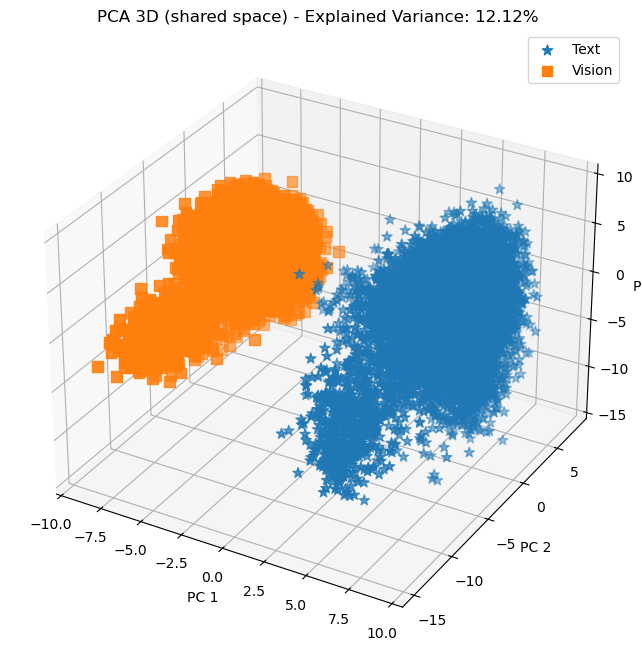

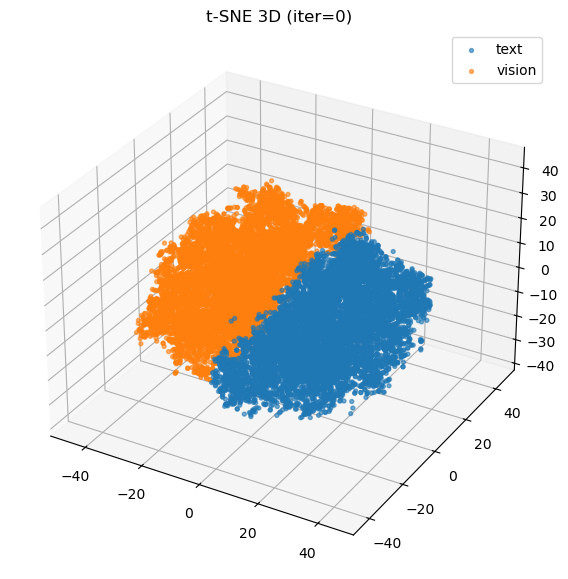

(array([[ 25.497347  , -19.17051   ,   3.7653964 ],
        [ 19.71704   ,  -7.7219625 , -20.193424  ],
        [  1.256957  ,   5.8411484 ,  -5.8121796 ],
        ...,
        [-29.736872  ,  16.672117  ,  12.820436  ],
        [-14.776919  ,  36.15816   ,   0.24911658],
        [  0.23788607,  24.142588  ,  10.4012375 ]], dtype=float32),
 array([0, 0, 0, ..., 1, 1, 1]))

In [5]:
visualize_3d(None, text_emb.numpy(), vision_emb.numpy(), iterations=0, save=False)
tsne_3d(None, text_emb.numpy(), vision_emb.numpy(), iterations=0)

### Diagnostic of the regime
- Are the embeddings already isometric between modalities?

In [5]:
def make_loaders(precomputed_dir, split_name="flickr30k", batch_size=256, seed=0, num_workers=0):
    ds = EmbeddingsDataset(precomputed_dir, split_name=split_name)
    n = len(ds)
    n_train = int(0.8 * n)
    n_test = n - n_train

    g = torch.Generator().manual_seed(seed)
    train_ds, test_ds = random_split(ds, [n_train, n_test], generator=g)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, test_loader

In [6]:
def collect_embeddings(loader, max_samples=5000, device="cpu"):
    """
    Collects (text, vision) pairs from loader into numpy arrays.
    Each batch is (text_emb, vision_emb).
    """
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b in tqdm(loader, desc=f"Collecting {max_samples} samples"):
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device), dim=-1).cpu().numpy()
            Xs.append(text_b); Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break
    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]
    return X, Y

def procrustes_T(X, Y, translate=True, scale=True):
    res = procrustes.generic(X, Y, translate=translate, scale=scale)
    T = res.t
    err = float(res.error) if not hasattr(res.error, "item") else float(res.error.item())
    return T, err

def isometry_checks(X, Y, T=None, k=10):
    """
    Checks if geometry is similar: correlation of intra-modality distances + kNN overlap.
    Uses cosine distance (since normalized).
    """
    X_use = X @ T if T is not None else X

    DX = cdist(X_use, X_use, metric="cosine")
    DY = cdist(Y,     Y,     metric="cosine")

    iu = np.triu_indices(DX.shape[0], k=1)
    corr = spearmanr(DX[iu], DY[iu]).correlation

    knn_X = np.argsort(DX, axis=1)[:, 1:k+1]
    knn_Y = np.argsort(DY, axis=1)[:, 1:k+1]
    overlaps = [len(set(knn_X[i]).intersection(set(knn_Y[i]))) / k for i in range(DX.shape[0])]

    return float(corr), float(np.mean(overlaps))

In [9]:
def regime_diagnostics(train_loader, n_pool=5000, n_trials=10, subset_small=100, subset_large=2000,
                       translate=True, scale=True, seed=0, device="cpu"):
    rng = np.random.default_rng(seed)
    X_pool, Y_pool = collect_embeddings(train_loader, max_samples=n_pool, device=device)

    # visualize on a subset
    tsne_3d(None, X_pool[:1000], Y_pool[:1000], iterations="train_pool")

    def run_trials(m):
        Ts, errs, corrs_b, corrs_a, ov_b, ov_a = [], [], [], [], [], []
        for _ in range(n_trials):
            idx = rng.choice(X_pool.shape[0], size=m, replace=False)
            Xs, Ys = X_pool[idx], Y_pool[idx]

            T, err = procrustes_T(Xs, Ys, translate=translate, scale=scale)
            Ts.append(T); errs.append(err)

            c0, o0 = isometry_checks(Xs, Ys, T=None, k=10)
            c1, o1 = isometry_checks(Xs, Ys, T=T,   k=10)
            corrs_b.append(c0); ov_b.append(o0)
            corrs_a.append(c1); ov_a.append(o1)

        # stability of T across trials
        dists = []
        for i in range(len(Ts)):
            for j in range(i+1, len(Ts)):
                dists.append(np.linalg.norm(Ts[i] - Ts[j], ord="fro"))
        return {
            "mean_T_fro_dist": float(np.mean(dists)) if dists else 0.0,
            "mean_procrustes_err": float(np.mean(errs)),
            "isom_corr_before": float(np.mean(corrs_b)),
            "isom_corr_after": float(np.mean(corrs_a)),
            "knn_overlap_before": float(np.mean(ov_b)),
            "knn_overlap_after": float(np.mean(ov_a)),
        }

    small = run_trials(subset_small)
    large = run_trials(subset_large)

    print("\n=== REGIME DIAGNOSTICS ===")
    print(f"[SMALL m={subset_small}]")
    for k,v in small.items(): print(f"  {k}: {v:.4f}")
    print(f"\n[LARGE m={subset_large}]")
    for k,v in large.items(): print(f"  {k}: {v:.4f}")

    return small, large

#### ANALISI:
- mean_T_fro_dist
È la distanza media (Frobenius) tra le matrici T ottenute in trial diversi (subset diversi). Intuitivamente: bassa → la trasformazione stimata è stabile (stessa “mappa” anche cambiando i campioni), alta → la trasformazione è instabile (dipende da quali esempi hai pescato)
Questa è la metrica più diretta per capire se esiste un global mapping consistente.

- mean_procrustes_err
È l’errore restituito da procrustes.generic sul subset: quanto “bene” T riesce ad allineare quel subset secondo l’obiettivo Procrustes (tipicamente un errore Frobenius normalizzato):
basso → facile allineare in quel subset,
alto → alignment difficile (o geometrie diverse)

- isom_corr_before
Calcolo del coefficiente di Spearman intramodale: costruzione della matrice di similarità del coseno per text-text e vision-vision e poi calcolo della somiglianza: alta somiglianza ==> geometria simile.

- isom_corr_after
Stesso test, ma dopo aver trasformato il testo con 
T: confronti distanze di 𝑋𝑇 con distanze di 𝑌.
se sale molto, la trasformazione rende le geometrie più simili → buon segno per un mapping rigido.

- knn_overlap_before
Per ogni punto 𝑖 prendi i suoi k-nearest neighbors nello spazio testo e nello spazio visione e calcola l’overlap. Poi fai la media su 𝑖.
alto → i vicinati locali sono simili tra modalità (struttura locale compatibile)
basso → vicinati diversi

- knn_overlap_after
Uguale, ma usando 𝑋𝑇 al posto di 𝑋. Se aumenta, 𝑇 sta rendendo più simili i vicinati tra modalità.

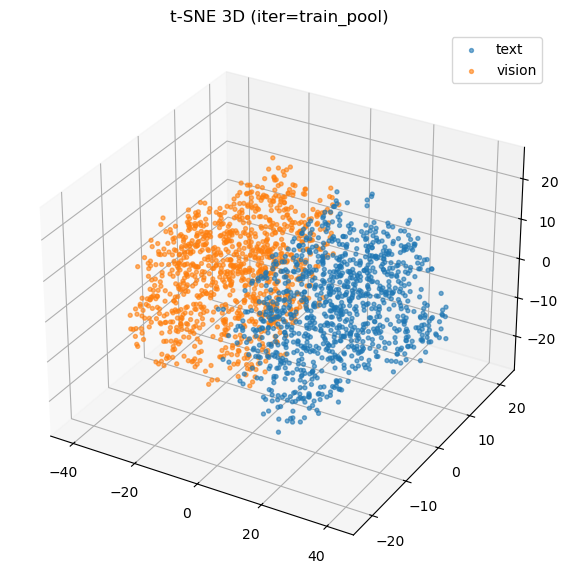


=== REGIME DIAGNOSTICS ===
[SMALL m=100]
  mean_T_fro_dist: 19.4794
  mean_procrustes_err: 0.0000
  isom_corr_before: 0.3281
  isom_corr_after: 0.7991
  knn_overlap_before: 0.3048
  knn_overlap_after: 0.7675

[LARGE m=2000]
  mean_T_fro_dist: 38.8199
  mean_procrustes_err: 0.5102
  isom_corr_before: 0.3127
  isom_corr_after: 0.5226
  knn_overlap_before: 0.1487
  knn_overlap_after: 0.2670


In [10]:
train_loader, test_loader = make_loaders(precomputed_dir, split_name="flickr30k", batch_size=256, seed=0, num_workers=0)

small_stats, large_stats = regime_diagnostics(
    train_loader,
    n_pool=5000,
    n_trials=10,
    subset_small=100,
    subset_large=2000,
    translate=True,
    scale=True,
    seed=0,
    device="cpu"
)

This results shows us (as expected) that the procrustes is sensitive to data sampling. The higher the "batch" the higher is the error and the lower is the ability of transformation matrix to induce similar geometry between data modalities.

Questi numeri suggeriscono:
- Procrustes su pochi campioni: può dare impressione di “quasi isometria” ma è probabilmente un fit locale / overfit.
- Procrustes su tanti campioni: rivela che la relazione non è una sola trasformazione globale; c’è eterogeneità (semantica o strutturale).

### Fit a more general procrustes


In [7]:
def fit_procrustes_on_10k(train_loader, n_fit=10_000, translate=True, scale=True, device="cpu"):
    X_fit, Y_fit = collect_embeddings(train_loader, max_samples=n_fit, device=device)
    res = procrustes.generic(X_fit, Y_fit, translate=translate, scale=scale)
    T = res.t
    fit_err = float(res.error) if not hasattr(res.error, "item") else float(res.error.item())

    # store preprocessing stats consistent with translate/scale (standard)
    mu_X = X_fit.mean(axis=0, keepdims=True)
    mu_Y = Y_fit.mean(axis=0, keepdims=True)
    eps = 1e-12
    s_X = np.linalg.norm(X_fit - mu_X, ord="fro") + eps
    s_Y = np.linalg.norm(Y_fit - mu_Y, ord="fro") + eps

    return {"T": T, "mu_X": mu_X, "mu_Y": mu_Y, "s_X": s_X, "s_Y": s_Y, "fit_error": fit_err}

In [8]:
def apply_mapping_np(X, Y, mapping, renorm=True):
    eps = 1e-12
    Xp = (X - mapping["mu_X"]) / mapping["s_X"]
    Yp = (Y - mapping["mu_Y"]) / mapping["s_Y"]
    X_al = Xp @ mapping["T"]
    Y_al = Yp
    if renorm:
        X_al = X_al / (np.linalg.norm(X_al, axis=1, keepdims=True) + eps)
        Y_al = Y_al / (np.linalg.norm(Y_al, axis=1, keepdims=True) + eps)
    return X_al, Y_al

def eval_test_pre_post( test_loader, mapping, gaps=('RMG','L2M','L2I'), device="cpu"):
    r_orig = {1: [], 5: [], 10: []}
    r_al   = {1: [], 5: [], 10: []}

    X_all, Y_all = [], []
    Xal_all, Yal_all = [], []

    with torch.no_grad():
        for text_b, vis_b in tqdm(test_loader, desc="Eval test pre/post"):
            X = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            Y = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()

            r_orig[1].append(retrieval(X, Y, top_k=1))
            r_orig[5].append(retrieval(X, Y, top_k=5))
            r_orig[10].append(retrieval(X, Y, top_k=10))

            X_al, Y_al = apply_mapping_np(X, Y, mapping, renorm=True)
            r_al[1].append(retrieval(X_al, Y_al, top_k=1))
            r_al[5].append(retrieval(X_al, Y_al, top_k=5))
            r_al[10].append(retrieval(X_al, Y_al, top_k=10))

            X_all.append(X); Y_all.append(Y)
            Xal_all.append(X_al); Yal_all.append(Y_al)

    X_all = np.concatenate(X_all, axis=0)
    Y_all = np.concatenate(Y_all, axis=0)
    Xal_all = np.concatenate(Xal_all, axis=0)
    Yal_all = np.concatenate(Yal_all, axis=0)

    gaps_orig, gaps_al = {}, {}
    for g in gaps:
        go = compute_gap( g, X_all, Y_all, iterations=None)
        ga = compute_gap( g, Xal_all, Yal_all, iterations=None)
        gaps_orig[g] = go["text_vision"] if isinstance(go, dict) and "text_vision" in go else go
        gaps_al[g]   = ga["text_vision"] if isinstance(ga, dict) and "text_vision" in ga else ga

    print("\n=== TEST RESULTS ===")
    print(f"Procrustes fit_error on 10k: {mapping['fit_error']:.6f}")
    print(f"Retrieval@1  orig: {np.mean(r_orig[1]):.4f} | aligned: {np.mean(r_al[1]):.4f}")
    print(f"Retrieval@5  orig: {np.mean(r_orig[5]):.4f} | aligned: {np.mean(r_al[5]):.4f}")
    print(f"Retrieval@10 orig: {np.mean(r_orig[10]):.4f} | aligned: {np.mean(r_al[10]):.4f}")
    print("Gaps original:", gaps_orig)
    print("Gaps aligned :", gaps_al)

    # t-SNE quick look
    tsne_3d(X_all[:1000], Y_all[:1000], iterations="test_orig")
    tsne_3d(Xal_all[:1000], Yal_all[:1000], iterations="test_aligned")

    return {
        "retrieval_orig": {k: float(np.mean(v)) for k,v in r_orig.items()},
        "retrieval_aligned": {k: float(np.mean(v)) for k,v in r_al.items()},
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_al
    }

Eval test pre/post: 100%|██████████| 25/25 [00:00<00:00, 217.55it/s]



=== TEST RESULTS ===
Procrustes fit_error on 10k: 0.648491
Retrieval@1  orig: 0.8746 | aligned: 0.7309
Retrieval@5  orig: 0.9742 | aligned: 0.9254
Retrieval@10 orig: 0.9877 | aligned: 0.9647
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924092292786, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.6547232304881285, 'L2M': 0.026744429022073746, 'L2I': 0.9641363024711609}


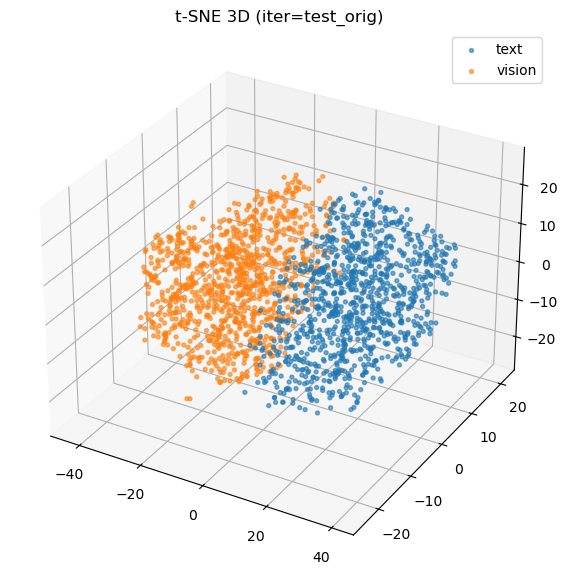

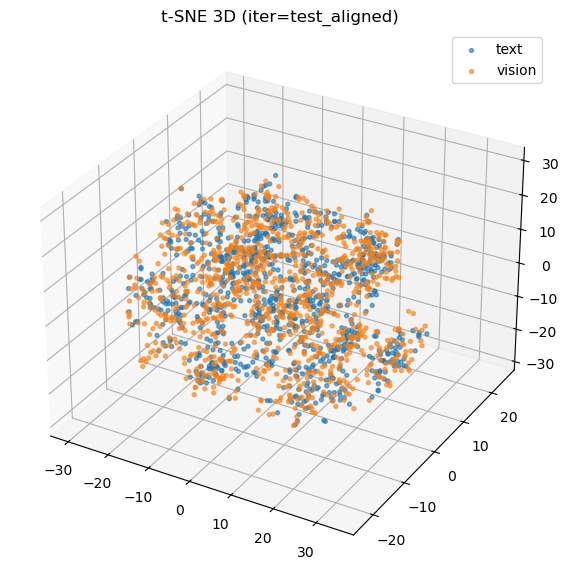

In [16]:
train_loader, test_loader = make_loaders(precomputed_dir, split_name="flickr30k", batch_size=256, seed=0, num_workers=0)

mapping_10k = fit_procrustes_on_10k(train_loader, n_fit=10_000, translate=True, scale=True, device="cpu")
test_stats = eval_test_pre_post(test_loader, mapping_10k, device="cpu")

In [20]:
# Export the mappping for potential reuse
import json
mapping_to_save = {
    "T": mapping_10k["T"].tolist(),  # Convert numpy array to list for JSON serialization
    "mu_X": mapping_10k["mu_X"].tolist(),
    "mu_Y": mapping_10k["mu_Y"].tolist(),
    "s_X": mapping_10k["s_X"].tolist(),
    "s_Y": mapping_10k["s_Y"].tolist(),
    "fit_error": mapping_10k["fit_error"]
}
with open("procrustes_mapping_10k.json", "w") as f:
    json.dump(mapping_to_save, f)   
    
    

### Subspace alignment

In [211]:
def fit_subspace_alignment(train_loader, n_fit=10_000, d_sub=256, device="cpu"):
    X, Y = collect_embeddings(train_loader, max_samples=n_fit, device=device)  # X=text, Y=vision

    # center (PCA-style)
    muX = X.mean(axis=0, keepdims=True)
    muY = Y.mean(axis=0, keepdims=True)
    Xc = X - muX
    Yc = Y - muY

    # SVD to get bases Ws, Wt (top d_sub right singular vectors)
    # Xc = U S V^T => Ws = V[:, :d_sub]
    _, _, VtX = np.linalg.svd(Xc, full_matrices=False)
    _, _, VtY = np.linalg.svd(Yc, full_matrices=False)

    Ws = VtX[:d_sub].T   # (D, d_sub)
    Wt = VtY[:d_sub].T   # (D, d_sub)

    # closed-form subspace alignment
    Phi = Wt.T @ Ws      # (d_sub, d_sub)   Eq (7) in the paper :contentReference[oaicite:4]{index=4}

    return {"muX": muX, "muY": muY, "Ws": Ws, "Wt": Wt, "Phi": Phi, "d_sub": d_sub}

In [212]:
def apply_subspace_alignment(X, Y, model, renorm=True):
    eps = 1e-12
    muX, muY = model["muX"], model["muY"]
    Ws, Wt, Phi = model["Ws"], model["Wt"], model["Phi"]

    # center
    Xc = X - muX
    Yc = Y - muY

    # align Y into X-space (Eq. 10 style) :contentReference[oaicite:6]{index=6}
    Y_al = Yc @ Wt @ Phi @ Ws.T

    # optionally bring back to X mean
    Y_al = Y_al + muX

    if renorm:
        Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)
        Yn = Y / (np.linalg.norm(Y, axis=1, keepdims=True) + eps)
        Yaln = Y_al / (np.linalg.norm(Y_al, axis=1, keepdims=True) + eps)
        return Xn, Yn, Yaln
    return X, Y, Y_al


def eval_subspace_alignment(test_loader, model, device="cpu", gaps=("RMG","L2M","L2I")):
    r_orig = {1: [], 5: [], 10: []}
    r_al   = {1: [], 5: [], 10: []}

    X_all, Y_all, Yal_all = [], [], []

    with torch.no_grad():
        for text_b, vis_b in tqdm(test_loader, desc="Eval subspace alignment"):
            X = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            Y = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()

            # original retrieval
            r_orig[1].append(retrieval(X, Y, top_k=1))
            r_orig[5].append(retrieval(X, Y, top_k=5))
            r_orig[10].append(retrieval(X, Y, top_k=10))

            # aligned vision -> text-space
            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, model, renorm=True)

            r_al[1].append(retrieval(Xn, Yaln, top_k=1))
            r_al[5].append(retrieval(Xn, Yaln, top_k=5))
            r_al[10].append(retrieval(Xn, Yaln, top_k=10))

            X_all.append(Xn); Y_all.append(Yn); Yal_all.append(Yaln)

    X_all = np.concatenate(X_all, axis=0)
    Y_all = np.concatenate(Y_all, axis=0)
    Yal_all = np.concatenate(Yal_all, axis=0)

    gaps_orig, gaps_al = {}, {}
    for g in gaps:
        go = compute_gap(g, X_all, Y_all, iterations=None)
        ga = compute_gap(g, X_all, Yal_all, iterations=None)
        gaps_orig[g] = go["text_vision"] if isinstance(go, dict) and "text_vision" in go else go
        gaps_al[g]   = ga["text_vision"] if isinstance(ga, dict) and "text_vision" in ga else ga

    print("\n=== SUBSPACE ALIGNMENT TEST RESULTS ===")
    print(f"d_sub = {model['d_sub']}")
    print(f"Retrieval@1  orig: {np.mean(r_orig[1]):.4f} | aligned: {np.mean(r_al[1]):.4f}")
    print(f"Retrieval@5  orig: {np.mean(r_orig[5]):.4f} | aligned: {np.mean(r_al[5]):.4f}")
    print(f"Retrieval@10 orig: {np.mean(r_orig[10]):.4f} | aligned: {np.mean(r_al[10]):.4f}")
    print("Gaps original:", gaps_orig)
    print("Gaps aligned :", gaps_al)

    return {
        "retrieval_orig": {k: float(np.mean(v)) for k,v in r_orig.items()},
        "retrieval_aligned": {k: float(np.mean(v)) for k,v in r_al.items()},
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_al
    }

In [213]:
# opzionale: prova diversi d_sub
for d in [32, 64, 128, 256, 384]:
    sub_model = fit_subspace_alignment(train_loader, n_fit=10_000, d_sub=d, device="cpu")
    _ = eval_subspace_alignment(test_loader, sub_model, device="cpu")

Eval subspace alignment: 100%|██████████| 25/25 [00:00<00:00, 198.42it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 32
Retrieval@1  orig: 0.8746 | aligned: 0.5478
Retrieval@5  orig: 0.9742 | aligned: 0.8462
Retrieval@10 orig: 0.9877 | aligned: 0.9223
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924688339233, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.7414979687714743, 'L2M': 0.30054745078086853, 'L2I': 0.8423372507095337}


Eval subspace alignment: 100%|██████████| 25/25 [00:00<00:00, 160.43it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 64
Retrieval@1  orig: 0.8746 | aligned: 0.7393
Retrieval@5  orig: 0.9742 | aligned: 0.9389
Retrieval@10 orig: 0.9877 | aligned: 0.9682
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924688339233, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.7144638116284577, 'L2M': 0.23709431290626526, 'L2I': 0.825964093208313}


Eval subspace alignment: 100%|██████████| 25/25 [00:00<00:00, 159.87it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 128
Retrieval@1  orig: 0.8746 | aligned: 0.8346
Retrieval@5  orig: 0.9742 | aligned: 0.9654
Retrieval@10 orig: 0.9877 | aligned: 0.9846
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924688339233, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.6990100149221713, 'L2M': 0.16596266627311707, 'L2I': 0.8335995078086853}


Eval subspace alignment: 100%|██████████| 25/25 [00:00<00:00, 160.43it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 256
Retrieval@1  orig: 0.8746 | aligned: 0.8598
Retrieval@5  orig: 0.9742 | aligned: 0.9713
Retrieval@10 orig: 0.9877 | aligned: 0.9855
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924688339233, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.7021362575148538, 'L2M': 0.08870168030261993, 'L2I': 0.8764083385467529}


Eval subspace alignment: 100%|██████████| 25/25 [00:00<00:00, 159.60it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 384
Retrieval@1  orig: 0.8746 | aligned: 0.8620
Retrieval@5  orig: 0.9742 | aligned: 0.9718
Retrieval@10 orig: 0.9877 | aligned: 0.9854
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924688339233, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.7102918219244718, 'L2M': 0.051042165607213974, 'L2I': 0.91037917137146}


Dimensione 256 ==> con subspace alignment posso ridurre il gap senza distruggere la performance

L’allineamento globale (Procrustes) riduce fortemente le distanze medie tra modalità (L2M, L2I) ma degrada le relazioni locali responsabili del retrieval. Subspace alignment, invece, agisce come un filtro: proiettando su un sottospazio principale e riallineando le basi, riduce il gap mantenendo quasi invariata la performance per  𝑑sub sufficientemente grande (≈256). Questo suggerisce che la discrepanza tra modalità è concentrata in componenti specifiche dello spazio, mentre un sottospazio semantico condiviso esiste e può essere allineato.

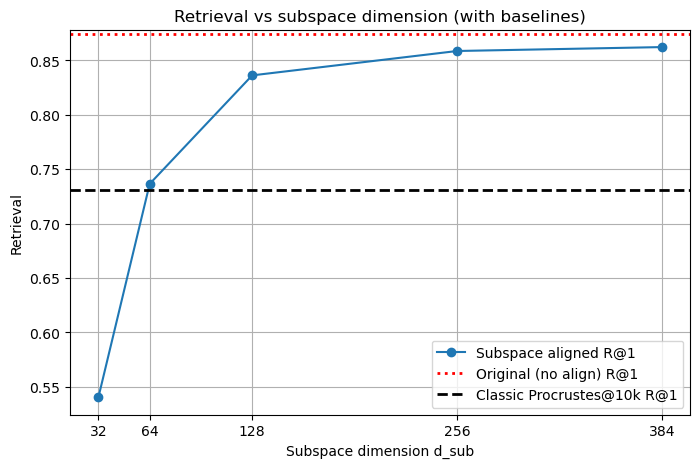

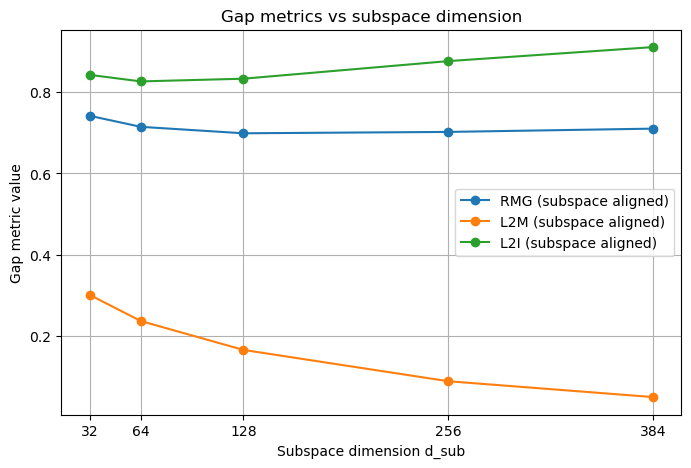

In [214]:
import numpy as np
import matplotlib.pyplot as plt

# --- Subspace sweep results (aligned) ---
results = [
    {"d_sub": 32,  "retrieval@1": 0.5406, "retrieval@5": 0.8407, "retrieval@10": 0.9180,
     "RMG": 0.7418968617387169, "L2M": 0.3014943301677704, "L2I": 0.8425172567367554},
    {"d_sub": 64,  "retrieval@1": 0.7365, "retrieval@5": 0.9356, "retrieval@10": 0.9671,
     "RMG": 0.7147150678988811, "L2M": 0.23713606595993042, "L2I": 0.8264103531837463},
    {"d_sub": 128, "retrieval@1": 0.8362, "retrieval@5": 0.9629, "retrieval@10": 0.9834,
     "RMG": 0.6988464308853876, "L2M": 0.16616225242614746, "L2I": 0.8330492377281189},
    {"d_sub": 256, "retrieval@1": 0.8586, "retrieval@5": 0.9715, "retrieval@10": 0.9849,
     "RMG": 0.7022089214672783, "L2M": 0.0890965685248375, "L2I": 0.8763177394866943},
    {"d_sub": 384, "retrieval@1": 0.8622, "retrieval@5": 0.9715, "retrieval@10": 0.9862,
     "RMG": 0.7102776515662346, "L2M": 0.05012039095163345, "L2I": 0.9108297228813171},
]

# --- Baselines ---
original_baseline = {"retrieval@1": 0.8746, "retrieval@5": 0.9742, "retrieval@10": 0.9877}
classic_procrustes = {"retrieval@1": 0.7309, "retrieval@5": 0.9254, "retrieval@10": 0.9647}

results = sorted(results, key=lambda x: x["d_sub"])
d = np.array([r["d_sub"] for r in results])

# -----------------------------
# Plot 1: Retrieval@k vs d_sub
#   - original baseline in RED
#   - classic procrustes baseline in BLACK
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(d, [r["retrieval@1"] for r in results], marker='o', label="Subspace aligned R@1")
# plt.plot(d, [r["retrieval@5"] for r in results], marker='o', label="Subspace aligned R@5")
# plt.plot(d, [r["retrieval@10"] for r in results], marker='o', label="Subspace aligned R@10")

# Original baseline (RED, dotted)
plt.axhline(original_baseline["retrieval@1"], color="red", linestyle=":", linewidth=2, label="Original (no align) R@1")
# plt.axhline(original_baseline["retrieval@5"], color="red", linestyle=":", linewidth=2, label="Original (no align) R@5")
# plt.axhline(original_baseline["retrieval@10"], color="red", linestyle=":", linewidth=2, label="Original (no align) R@10")

# Classic Procrustes baseline (BLACK, dashed)
plt.axhline(classic_procrustes["retrieval@1"], color="black", linestyle="--", linewidth=2, label="Classic Procrustes@10k R@1")
# plt.axhline(classic_procrustes["retrieval@5"], color="black", linestyle="--", linewidth=2, label="Classic Procrustes@10k R@5")
# plt.axhline(classic_procrustes["retrieval@10"], color="black", linestyle="--", linewidth=2, label="Classic Procrustes@10k R@10")

plt.xlabel("Subspace dimension d_sub")
plt.ylabel("Retrieval")
plt.title("Retrieval vs subspace dimension (with baselines)")
plt.xticks(d)
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot 2: Gap metrics vs d_sub
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(d, [r["RMG"] for r in results], marker='o', label="RMG (subspace aligned)")
plt.plot(d, [r["L2M"] for r in results], marker='o', label="L2M (subspace aligned)")
plt.plot(d, [r["L2I"] for r in results], marker='o', label="L2I (subspace aligned)")

plt.xlabel("Subspace dimension d_sub")
plt.ylabel("Gap metric value")
plt.title("Gap metrics vs subspace dimension")
plt.xticks(d)
plt.grid(True)
plt.legend()
plt.show()

### Analisi del subspace alignment con d_sub 256

Abbiamo visto che con 256 riusciamo a mantenere il Retrieval@1, ciò vuol dire che esiste un sottospazio vettoriale che ci rappresenta la stessa semantica e che comprime le informazioni. Q \n
Adesso ci serve un modo per mappare le 256 dimensioni del sottospazio sulle D (512) dimensioni originali. 

In [215]:
sub_model = fit_subspace_alignment(train_loader, n_fit=10_000, d_sub=256, device="cpu")
_ = eval_subspace_alignment(test_loader, sub_model, device="cpu")

Eval subspace alignment: 100%|██████████| 25/25 [00:00<00:00, 156.37it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 256
Retrieval@1  orig: 0.8746 | aligned: 0.8599
Retrieval@5  orig: 0.9742 | aligned: 0.9724
Retrieval@10 orig: 0.9877 | aligned: 0.9860
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924688339233, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.7021417575898428, 'L2M': 0.08959619700908661, 'L2I': 0.8760488629341125}


### Analysis of the subspace alignment method

In [216]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import spearmanr

def collect_embeddings_from_embedding_loader(loader, max_samples=20000, device="cpu"):
    """
    loader yields (text_emb, vision_emb) already computed.
    Returns X (text) and Y (vision) as numpy arrays [N,D], L2-normalized.
    """
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b in tqdm(loader, desc=f"Collecting {max_samples} pairs"):
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()
            Xs.append(text_b)
            Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break
    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]
    return X, Y

def normalize01(v, eps=1e-12):
    v = v.astype(np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)

def analyze_gap_vs_subspace_importance(
    loader,
    sub_model,
    max_samples=20000,
    top_k=50,
    device="cpu"
):
    """
    sub_model must contain:
      - Ws: (D, d_sub) text basis
      - Wt: (D, d_sub) vision basis
      - d_sub: int
    """
    Ws = sub_model["Ws"]   # (D, d_sub)
    Wt = sub_model["Wt"]   # (D, d_sub)
    d_sub = sub_model.get("d_sub", Ws.shape[1])

    # 1) sample embeddings to compute per-dimension mean gap
    X, Y = collect_embeddings_from_embedding_loader(loader, max_samples=max_samples, device=device)
    D = X.shape[1]

    muX = X.mean(axis=0)  # (D,)
    muY = Y.mean(axis=0)  # (D,)

    gap_dim = np.abs(muX - muY)  # (D,) abs mean diff per dimension

    # 2) subspace importance per original dim
    imp_X = np.sum(Ws**2, axis=1)  # (D,)
    imp_Y = np.sum(Wt**2, axis=1)  # (D,)
    imp_joint = 0.5 * (imp_X + imp_Y)

    # 3) correlations (rank-based, robust)
    rho_x = spearmanr(gap_dim, imp_X).correlation
    rho_y = spearmanr(gap_dim, imp_Y).correlation
    rho_j = spearmanr(gap_dim, imp_joint).correlation

    # 4) top-k overlaps
    top_gap = np.argsort(-gap_dim)[:top_k]
    top_impX = np.argsort(-imp_X)[:top_k]
    top_impY = np.argsort(-imp_Y)[:top_k]
    top_impJ = np.argsort(-imp_joint)[:top_k]

    def overlap(a, b):
        return len(set(a).intersection(set(b)))

    ov_x = overlap(top_gap, top_impX)
    ov_y = overlap(top_gap, top_impY)
    ov_j = overlap(top_gap, top_impJ)

    print(f"\n=== Gap vs Subspace Importance (d_sub={d_sub}, N={X.shape[0]}, D={D}) ===")
    print(f"Spearman corr(gap_dim, imp_X)     = {rho_x:.4f}")
    print(f"Spearman corr(gap_dim, imp_Y)     = {rho_y:.4f}")
    print(f"Spearman corr(gap_dim, imp_joint) = {rho_j:.4f}")
    print(f"\nTop-{top_k} overlap:")
    print(f"  overlap(top gap, top imp_X) = {ov_x}/{top_k}")
    print(f"  overlap(top gap, top imp_Y) = {ov_y}/{top_k}")
    print(f"  overlap(top gap, top imp_J) = {ov_j}/{top_k}")

    # 5) plots (normalized to [0,1] so they are comparable)
    gap_n = normalize01(gap_dim)
    impX_n = normalize01(imp_X)
    impY_n = normalize01(imp_Y)
    impJ_n = normalize01(imp_joint)

    plt.figure(figsize=(10, 4))
    plt.plot(gap_n, label="gap per-dim |mean(text)-mean(vision)| (norm)")
    plt.plot(impJ_n, label="subspace importance joint (norm)")
    plt.title(f"Gap-per-dimension vs Subspace importance (d_sub={d_sub})")
    plt.xlabel("Original embedding dimension")
    plt.ylabel("Normalized value")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.scatter(gap_dim, imp_joint, s=8, alpha=0.5)
    plt.title(f"Scatter: gap_dim vs imp_joint (Spearman={rho_j:.3f})")
    plt.xlabel("gap_dim = |mean_x - mean_y|")
    plt.ylabel("imp_joint = 0.5(||Ws[j]||^2 + ||Wt[j]||^2)")
    plt.grid(True)
    plt.show()

    # 6) show top dims (useful for inspection)
    print("\nTop dims by GAP (abs mean diff):")
    for idx in top_gap[:min(20, top_k)]:
        print(f"  dim {idx:4d} | gap={gap_dim[idx]:.6f} | impJ={imp_joint[idx]:.6f}")

    print("\nTop dims by subspace importance (joint):")
    for idx in top_impJ[:min(20, top_k)]:
        print(f"  dim {idx:4d} | impJ={imp_joint[idx]:.6f} | gap={gap_dim[idx]:.6f}")

    return {
        "gap_dim": gap_dim,
        "imp_X": imp_X,
        "imp_Y": imp_Y,
        "imp_joint": imp_joint,
        "rho": {"gap_impX": rho_x, "gap_impY": rho_y, "gap_impJ": rho_j},
        "top": {"gap": top_gap, "impX": top_impX, "impY": top_impY, "impJ": top_impJ},
        "overlap": {"gap_impX": ov_x, "gap_impY": ov_y, "gap_impJ": ov_j},
    }


=== Gap vs Subspace Importance (d_sub=256, N=20000, D=512) ===
Spearman corr(gap_dim, imp_X)     = 0.1847
Spearman corr(gap_dim, imp_Y)     = 0.2526
Spearman corr(gap_dim, imp_joint) = 0.2426

Top-512 overlap:
  overlap(top gap, top imp_X) = 512/512
  overlap(top gap, top imp_Y) = 512/512
  overlap(top gap, top imp_J) = 512/512


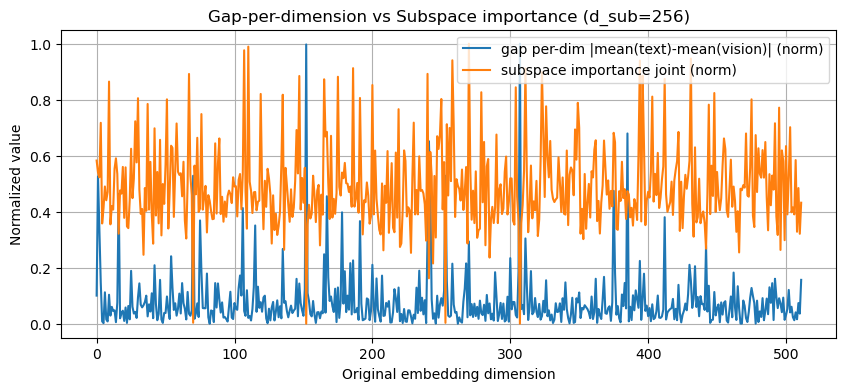

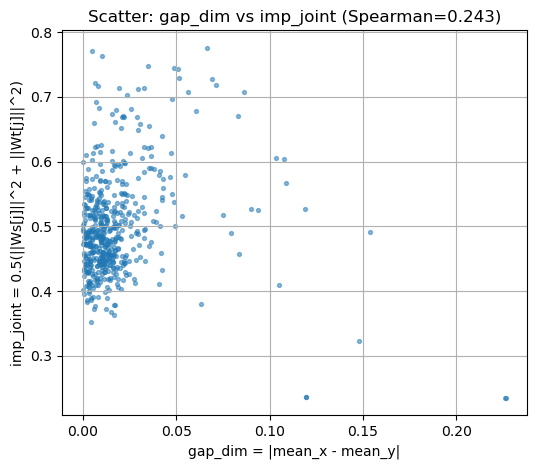


Top dims by GAP (abs mean diff):
  dim  307 | gap=0.226579 | impJ=0.235036
  dim  152 | gap=0.225968 | impJ=0.235051
  dim  385 | gap=0.153968 | impJ=0.491166
  dim  241 | gap=0.147679 | impJ=0.322766
  dim   70 | gap=0.119772 | impJ=0.236903
  dim  253 | gap=0.119728 | impJ=0.236731
  dim    1 | gap=0.119187 | impJ=0.527164
  dim  242 | gap=0.108679 | impJ=0.566902
  dim  375 | gap=0.107539 | impJ=0.603739
  dim   16 | gap=0.105052 | impJ=0.408864
  dim  167 | gap=0.103173 | impJ=0.605594
  dim  106 | gap=0.093617 | impJ=0.524585
  dim  178 | gap=0.090149 | impJ=0.526952
  dim  412 | gap=0.086198 | impJ=0.707885
  dim   75 | gap=0.083594 | impJ=0.457638
  dim  191 | gap=0.083028 | impJ=0.671043
  dim  115 | gap=0.079523 | impJ=0.489582
  dim    2 | gap=0.075284 | impJ=0.517821
  dim  240 | gap=0.071229 | impJ=0.717556
  dim  311 | gap=0.069031 | impJ=0.727977

Top dims by subspace importance (joint):
  dim  270 | impJ=0.775789 | gap=0.066564
  dim  110 | impJ=0.770197 | gap=0.004753


In [217]:
analysis = analyze_gap_vs_subspace_importance(
    loader=train_loader,     # oppure un loader dedicato per stimare mean gap (train meglio)
    sub_model=sub_model,     # quello fit con d_sub=256
    max_samples=20000,       # aumenta a 50k se vuoi stime più stabili
    top_k=512,
    device="cpu"
)

possiamo provare a fattorizzare uno spazio latente multimodale a d dimensioni dove per ogni dimensione valutiamo:
- come agisce sul gap
- quanto è utile per la semantica

Selezionare n dimensioni con gap alto e rimuoverle e runnare retrieval 
Stessa cosa per le dimensioni cons emantica alta

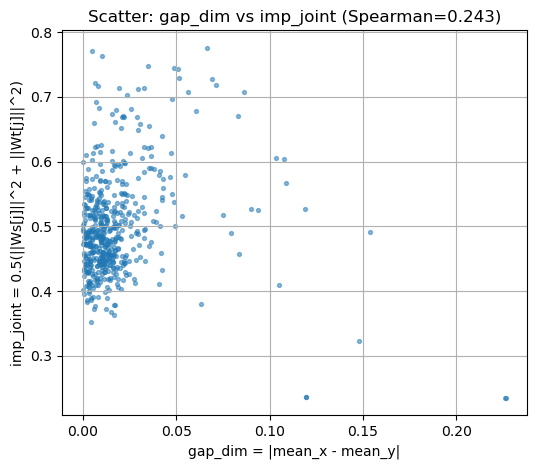

In [218]:
# Plot on a 2d scatter the gap_dim vs imp_joint
def plot_gap_vs_importance_scatter(analysis):
    gap_dim = analysis["gap_dim"]
    imp_joint = analysis["imp_joint"]
    rho_j = analysis["rho"]["gap_impJ"]

    plt.figure(figsize=(6, 5))
    plt.scatter(gap_dim, imp_joint, s=8, alpha=0.5)
    plt.title(f"Scatter: gap_dim vs imp_joint (Spearman={rho_j:.3f})")
    plt.xlabel("gap_dim = |mean_x - mean_y|")
    plt.ylabel("imp_joint = 0.5(||Ws[j]||^2 + ||Wt[j]||^2)")
    plt.grid(True)
    plt.show()
    
plot_gap_vs_importance_scatter(analysis)

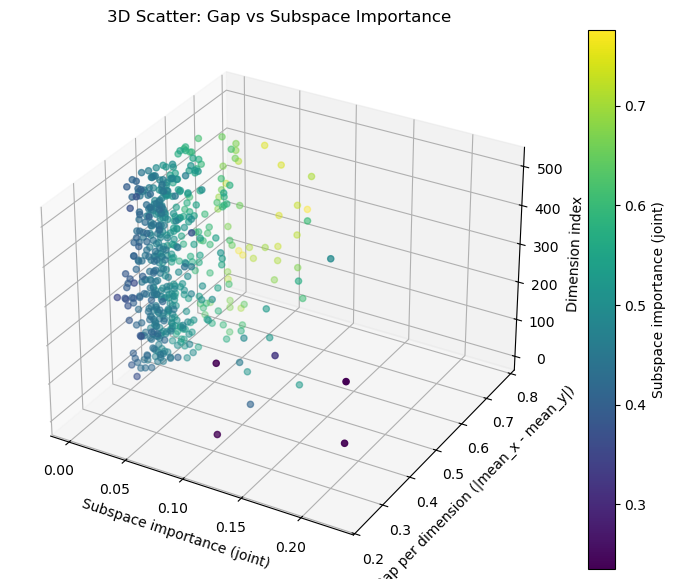

In [219]:
# Plot on a 3d scatter the gap_dim vs imp_joint and dim index, color by importance
from mpl_toolkits.mplot3d import Axes3D
def plot_gap_vs_importance_3d(gap_dim, imp_joint):
    D = len(gap_dim)
    dims = np.arange(D)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(gap_dim, imp_joint, dims, c=imp_joint, cmap='viridis', s=20)
    plt.colorbar(sc, label='Subspace importance (joint)')
    ax.set_zlabel('Dimension index')
    ax.set_ylabel('Gap per dimension (|mean_x - mean_y|)')
    ax.set_xlabel('Subspace importance (joint)')
    ax.set_title('3D Scatter: Gap vs Subspace Importance')
    plt.show()
    
plot_gap_vs_importance_3d(analysis["gap_dim"], analysis["imp_joint"])


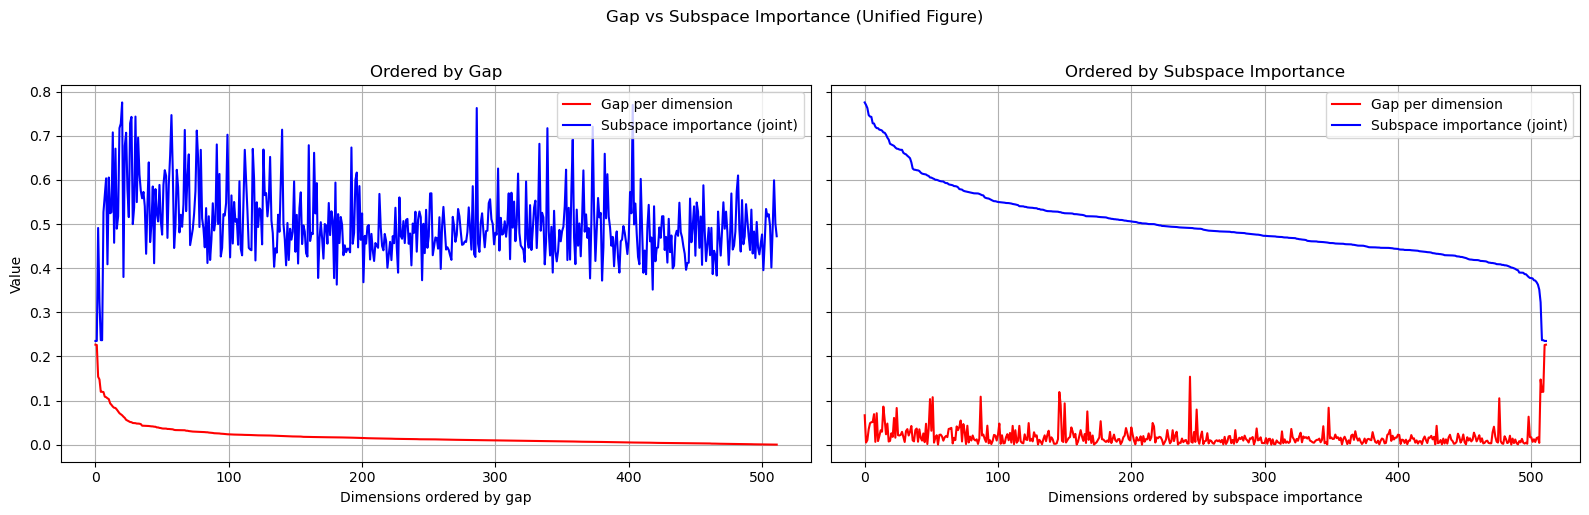

In [220]:
# Unified plot: both orderings in a single figure
def plot_gap_importance_unified(analysis):
    gap_dim = analysis["gap_dim"]
    imp_joint = analysis["imp_joint"]

    # Orders
    order_gap = np.argsort(-gap_dim)
    order_imp = np.argsort(-imp_joint)

    # Sorted values
    gap_by_gap = gap_dim[order_gap]
    imp_by_gap = imp_joint[order_gap]

    gap_by_imp = gap_dim[order_imp]
    imp_by_imp = imp_joint[order_imp]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    # Left: ordered by gap
    axes[0].plot(gap_by_gap, label="Gap per dimension", color="red")
    axes[0].plot(imp_by_gap, label="Subspace importance (joint)", color="blue")
    axes[0].set_title("Ordered by Gap")
    axes[0].set_xlabel("Dimensions ordered by gap")
    axes[0].set_ylabel("Value")
    axes[0].grid(True)
    axes[0].legend()

    # Right: ordered by importance
    axes[1].plot(gap_by_imp, label="Gap per dimension", color="red")
    axes[1].plot(imp_by_imp, label="Subspace importance (joint)", color="blue")
    axes[1].set_title("Ordered by Subspace Importance")
    axes[1].set_xlabel("Dimensions ordered by subspace importance")
    axes[1].grid(True)
    axes[1].legend()

    plt.suptitle("Gap vs Subspace Importance (Unified Figure)", y=1.02)
    plt.tight_layout()
    plt.show()

plot_gap_importance_unified(analysis)


#### Retrieval and clustering with top k selection strategies for retrieval/clustering
Thanks to the subspace alignment now we know which dims have most value for semantics.

In [221]:
train_loader , test_loader = make_loaders(precomputed_dir, split_name="flickr30k", batch_size=256, seed=0, num_workers=0)

In [222]:
gaps = ['RMG', 'L2M', 'L2I']
results_original = {
    'gap' : {
        'RMG': [],
        'L2M': [],
        'L2I': []
    },
    'retrieval': {
        1: [],
        5: [],
        10: []
    }
}

with torch.no_grad():
    for batch in test_loader:
        text_emb, vision_emb = batch
        retrieval_original = retrieval(text_emb.numpy(), vision_emb.numpy(), top_k=1)
        results_original['retrieval'][1].append(retrieval_original)
        retrieval_original_5 = retrieval(text_emb.numpy(), vision_emb.numpy(), top_k=5)
        results_original['retrieval'][5].append(retrieval_original_5)
        retrieval_original_10 = retrieval(text_emb.numpy(), vision_emb.numpy(), top_k=10)
        results_original['retrieval'][10].append(retrieval_original_10)
        for gap in gaps:
            gap_result = compute_gap(gap, text_emb.numpy(), vision_emb.numpy(), iterations=None)
            if isinstance(gap_result, dict) and "text_vision" in gap_result:
                results_original['gap'][gap].append(gap_result["text_vision"])
                
# Compute averages
avg_retrieval_original = {k: float(np.mean(v)) for k, v in results_original['retrieval'].items()}
avg_gaps_original = {gap: float(np.mean(v)) for gap, v in results_original['gap'].items()}



print("\n=== Original (no alignment) with all dimensions ===")
print(f"Average Retrieval@1: {avg_retrieval_original[1]:.4f}")
print(f"Average Retrieval@5: {avg_retrieval_original[5]:.4f}")
print(f"Average Retrieval@10: {avg_retrieval_original[10]:.4f}")
print("Average Gaps:")
for gap, avg in avg_gaps_original.items():
    print(f"  {gap}: {avg:.4f}")


=== Original (no alignment) with all dimensions ===
Average Retrieval@1: 0.8746
Average Retrieval@5: 0.9742
Average Retrieval@10: 0.9877
Average Gaps:
  RMG: 0.7976
  L2M: 0.6870
  L2I: 1.1637


In [223]:
sub_model = fit_subspace_alignment(train_loader, n_fit=10_000, d_sub=256, device="cpu")

In [224]:
result_entire_subspace = eval_subspace_alignment(test_loader, sub_model, device="cpu")

Eval subspace alignment: 100%|██████████| 25/25 [00:00<00:00, 163.77it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 256
Retrieval@1  orig: 0.8746 | aligned: 0.8612
Retrieval@5  orig: 0.9742 | aligned: 0.9709
Retrieval@10 orig: 0.9877 | aligned: 0.9860
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924688339233, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.7021803544773859, 'L2M': 0.08884423226118088, 'L2I': 0.8764086365699768}


In [225]:
# Given the importance of each dimension
def retrieval_with_top_k_dims_semantic_importance(test_loader, top_k_dims, subspace_alignment_model, device="cpu"):
    r_orig = {1: [], 5: [], 10: []}
    r_al   = {1: [], 5: [], 10: []}
    gaps = ['RMG', 'L2M', 'L2I']
    gaps_orig = {g: [] for g in gaps}
    gaps_al = {g: [] for g in gaps}

    with torch.no_grad():
        for text_b, vis_b in tqdm(test_loader, desc=f"Retrieval with top-{len(top_k_dims)} dims"):
            X = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            Y = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()

            # original retrieval on top-k dims
            r_orig[1].append(retrieval(X[:, top_k_dims], Y[:, top_k_dims], top_k=1))
            r_orig[5].append(retrieval(X[:, top_k_dims], Y[:, top_k_dims], top_k=5))
            r_orig[10].append(retrieval(X[:, top_k_dims], Y[:, top_k_dims], top_k=10))
            
            # compute gaps on top-k dims
            for g in gaps:
                go = compute_gap(g, X[:, top_k_dims], Y[:, top_k_dims], iterations=None)
                gaps_orig[g].append(go["text_vision"] if isinstance(go, dict) and "text_vision" in go else go)
                

            # aligned vision -> text-space on top-k dims
            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, subspace_alignment_model, renorm=True)
            r_al[1].append(retrieval(Xn[:, top_k_dims], Yaln[:, top_k_dims], top_k=1))
            r_al[5].append(retrieval(Xn[:, top_k_dims], Yaln[:, top_k_dims], top_k=5))
            r_al[10].append(retrieval(Xn[:, top_k_dims], Yaln[:, top_k_dims], top_k=10))
            
            for g in gaps:
                ga = compute_gap(g, Xn[:, top_k_dims], Yaln[:, top_k_dims], iterations=None)
                gaps_al[g].append(ga["text_vision"] if isinstance(ga, dict) and "text_vision" in ga else ga)
            
            

    print(f"\n=== Retrieval with Top-{len(top_k_dims)} Dims ({len(top_k_dims)} most important) ===")
    print(f"Retrieval@1  orig: {np.mean(r_orig[1]):.4f} | aligned: {np.mean(r_al[1]):.4f}")
    print(f"Retrieval@5  orig: {np.mean(r_orig[5]):.4f} | aligned: {np.mean(r_al[5]):.4f}")
    print(f"Retrieval@10 orig: {np.mean(r_orig[10]):.4f} | aligned: {np.mean(r_al[10]):.4f}")
    print("Gaps")
    for g in gaps:
        print(f"{g}  orig: {np.mean(gaps_orig[g]):.4f} | aligned: {np.mean(gaps_al[g]):.4f}")
        
    return  {
        "retrieval_orig": {k: float(np.mean(v)) for k,v in r_orig.items()},
        "retrieval_aligned": {k: float(np.mean(v)) for k,v in r_al.items()},
        "gaps_orig": {g: float(np.mean(v)) for g,v in gaps_orig.items()},
        "gaps_aligned": {g: float(np.mean(v)) for g,v in gaps_al.items()}
    }

#### Plot using top dim by importance

In [226]:
# Retrieval sul test set usando solo le top-k dimensioni più importanti (per subspace importance)
k_sweep = [10, 50, 100, 256, 384, 512]
k_sweep_result_joint = dict()
k_sweep_result_text = dict()
k_sweep_result_vision = dict()

# Importance joint
for k in k_sweep:
    top_k_dims_joint = analysis["top"]["impJ"][:k]  # top-k by joint importance
    k_sweep_result_joint[k] = retrieval_with_top_k_dims_semantic_importance(test_loader, top_k_dims_joint,sub_model, device="cpu")

    top_k_dims_text = analysis["top"]["impX"][:k]  # top-k by text importance
    k_sweep_result_text[k] = retrieval_with_top_k_dims_semantic_importance(test_loader, top_k_dims_text, sub_model, device="cpu")
    
    top_k_dims_vision = analysis["top"]["impY"][:k]  # top-k by vision importance
    k_sweep_result_vision[k] = retrieval_with_top_k_dims_semantic_importance(test_loader, top_k_dims_vision, sub_model, device="cpu")

Retrieval with top-10 dims: 100%|██████████| 25/25 [00:01<00:00, 15.87it/s]



=== Retrieval with Top-10 Dims (10 most important) ===
Retrieval@1  orig: 0.0593 | aligned: 0.0673
Retrieval@5  orig: 0.1907 | aligned: 0.2082
Retrieval@10 orig: 0.3001 | aligned: 0.3289
Gaps
RMG  orig: 0.7480 | aligned: 0.6392
L2M  orig: 0.1531 | aligned: 0.0248
L2I  orig: 0.2508 | aligned: 0.1914


Retrieval with top-10 dims: 100%|██████████| 25/25 [00:01<00:00, 15.68it/s]



=== Retrieval with Top-10 Dims (10 most important) ===
Retrieval@1  orig: 0.0333 | aligned: 0.0428
Retrieval@5  orig: 0.1276 | aligned: 0.1512
Retrieval@10 orig: 0.2114 | aligned: 0.2455
Gaps
RMG  orig: 0.7673 | aligned: 0.6795
L2M  orig: 0.1458 | aligned: 0.0305
L2I  orig: 0.2460 | aligned: 0.1936


Retrieval with top-10 dims: 100%|██████████| 25/25 [00:01<00:00, 15.63it/s]


...


=== Retrieval with Top-512 Dims (512 most important) ===
Retrieval@1  orig: 0.8746 | aligned: 0.8612
Retrieval@5  orig: 0.9742 | aligned: 0.9709
Retrieval@10 orig: 0.9877 | aligned: 0.9860
Gaps
RMG  orig: 0.7976 | aligned: 0.7021
L2M  orig: 0.6870 | aligned: 0.1037
L2I  orig: 1.1637 | aligned: 0.8764


Retrieval with top-512 dims: 100%|██████████| 25/25 [00:06<00:00,  3.62it/s]



=== Retrieval with Top-512 Dims (512 most important) ===
Retrieval@1  orig: 0.8746 | aligned: 0.8612
Retrieval@5  orig: 0.9742 | aligned: 0.9709
Retrieval@10 orig: 0.9877 | aligned: 0.9860
Gaps
RMG  orig: 0.7976 | aligned: 0.7021
L2M  orig: 0.6870 | aligned: 0.1037
L2I  orig: 1.1637 | aligned: 0.8764


Retrieval with top-512 dims: 100%|██████████| 25/25 [00:07<00:00,  3.55it/s]


=== Retrieval with Top-512 Dims (512 most important) ===
Retrieval@1  orig: 0.8746 | aligned: 0.8612
Retrieval@5  orig: 0.9742 | aligned: 0.9709
Retrieval@10 orig: 0.9877 | aligned: 0.9860
Gaps
RMG  orig: 0.7976 | aligned: 0.7021
L2M  orig: 0.6870 | aligned: 0.1037
L2I  orig: 1.1637 | aligned: 0.8764


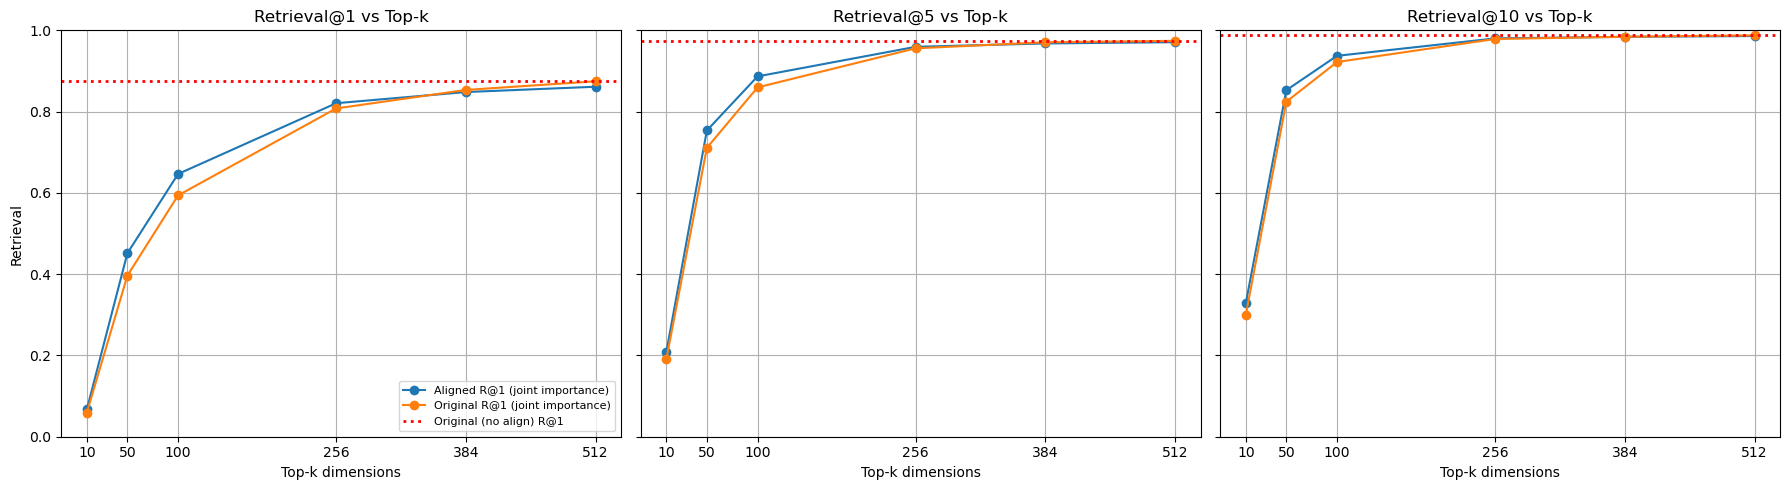

In [227]:
# Plot retrieval@1, retrieval@5, retrieval@10 vs k for the three importance criteria
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, rk in zip(axes, [1, 5, 10]):
    ax.plot(
        k_sweep,
        [k_sweep_result_joint[k]["retrieval_aligned"][rk] for k in k_sweep],
        marker="o",
        label=f"Aligned R@{rk} (joint importance)"
    )
    
    ax.plot(
        k_sweep,
        [k_sweep_result_joint[k]["retrieval_orig"][rk] for k in k_sweep],
        marker="o",
        label=f"Original R@{rk} (joint importance)"
    )
    # ax.plot(
    #     k_sweep,
    #     [k_sweep_result_text[k]["retrieval_aligned"][rk] for k in k_sweep],
    #     marker="o",
    #     label=f"Aligned R@{rk} (text importance)"
    # )
    
    # ax.plot(
    #     k_sweep,
    #     [k_sweep_result_text[k]["retrieval_orig"][rk] for k in k_sweep],
    #     marker="o",
    #     label=f"Original R@{rk} (text importance)"
    # )
    # ax.plot(
    #     k_sweep,
    #     [k_sweep_result_vision[k]["retrieval_aligned"][rk] for k in k_sweep],
    #     marker="o",
    #     label=f"Aligned R@{rk} (vision importance)"
    # )
    # ax.plot(
    #     k_sweep,
    #     [k_sweep_result_vision[k]["retrieval_orig"][rk] for k in k_sweep],
    #     marker="o",
    #     label=f"Original R@{rk} (vision importance)"
    # )
    
    ax.axhline(
        avg_retrieval_original[rk],
        color="red",
        linestyle=":",
        linewidth=2,
        label=f"Original (no align) R@{rk}"
    )
    ax.set_title(f"Retrieval@{rk} vs Top-k")
    ax.set_xlabel("Top-k dimensions")
    ax.set_xticks(k_sweep)
    ax.set_ylim(0, 1.0)
    ax.grid(True)

axes[0].set_ylabel("Retrieval")
axes[0].legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

In [228]:
# Fai una tabella con i risultati di retrieval@1 per tutti i k e le tre importanze
import pandas as pd
table_data = []
for k in k_sweep:
    row = {
        "Top-k": k,
        "Original R@1 (joint)": k_sweep_result_joint[k]["retrieval_orig"][1],
        "Aligned R@1 (joint)": k_sweep_result_joint[k]["retrieval_aligned"][1],
    }
    table_data.append(row)
    
df = pd.DataFrame(table_data)
print(df.to_string(index=False))


 Top-k  Original R@1 (joint)  Aligned R@1 (joint)
    10              0.059255             0.067255
    50              0.396305             0.451404
   100              0.593817             0.646510
   256              0.807769             0.820645
   384              0.853334             0.848146
   512              0.874586             0.861210


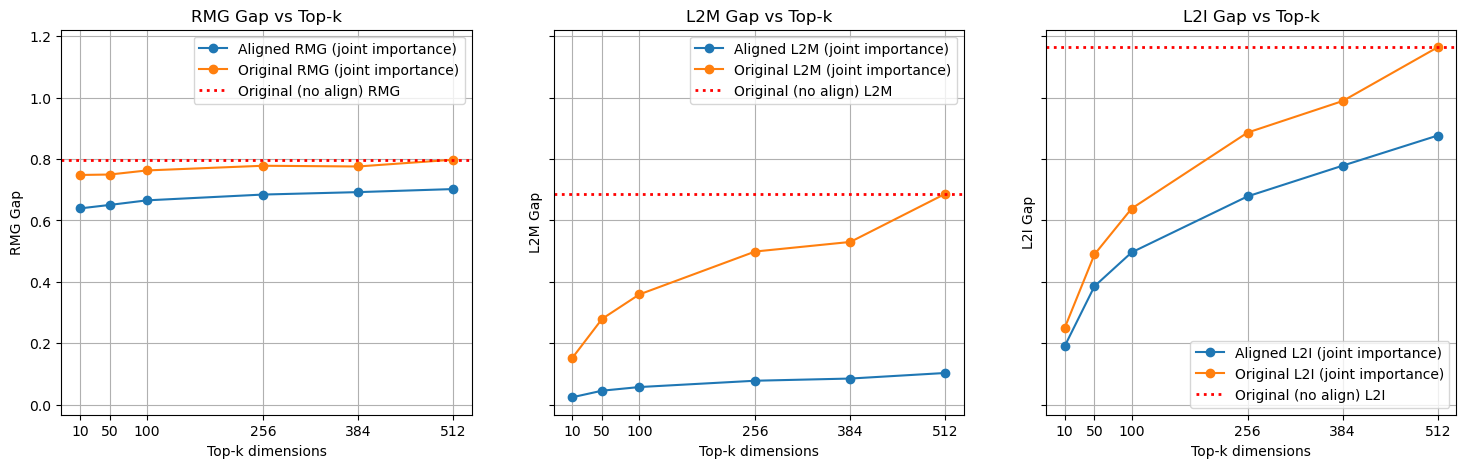

In [229]:
# Plot Gaps vs k for the three importance criteria
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
gaps = ['RMG', 'L2M', 'L2I']
for ax, g in zip(axes, gaps):
    ax.plot(
        k_sweep,
        [k_sweep_result_joint[k]["gaps_aligned"][g] for k in k_sweep],
        marker="o",
        label=f"Aligned {g} (joint importance)"
    )
    # ax.plot(
    #     k_sweep,
    #     [k_sweep_result_text[k]["gaps_aligned"][g] for k in k_sweep],
    #     marker="o",
    #     label=f"Aligned {g} (text importance)"
    # )
    # ax.plot(
    #     k_sweep,
    #     [k_sweep_result_vision[k]["gaps_aligned"][g] for k in k_sweep],
    #     marker="o",
    #     label=f"Aligned {g} (vision importance)"
    # )
    # Original gaps
    ax.plot(
        k_sweep,
        [k_sweep_result_joint[k]["gaps_orig"][g] for k in k_sweep],
        marker="o",
        label=f"Original {g} (joint importance)"
    )
    # ax.plot(
    #     k_sweep,
    #     [k_sweep_result_text[k]["gaps_orig"][g] for k in k_sweep],
    #     marker="o",
    #     label=f"Original {g} (text importance)"
    # )
    # ax.plot(
    #     k_sweep,
    #     [k_sweep_result_vision[k]["gaps_orig"][g] for k in k_sweep],
    #     marker="o",
    #     label=f"Original {g} (vision importance)"
    # )
    ax.axhline(
        avg_gaps_original[g],
        color="red",
        linestyle=":",
        linewidth=2,
        label=f"Original (no align) {g}"
    )
    ax.set_title(f"{g} Gap vs Top-k")
    ax.set_xlabel("Top-k dimensions")
    ax.set_xticks(k_sweep)
    # legends
    if g == 'RMG':
        ax.set_ylabel("RMG Gap")
    elif g == 'L2M':
        ax.set_ylabel("L2M Gap")
    elif g == 'L2I':
        ax.set_ylabel("L2I Gap")    
    
    #plot legend
    ax.legend()
        
    ax.grid(True)

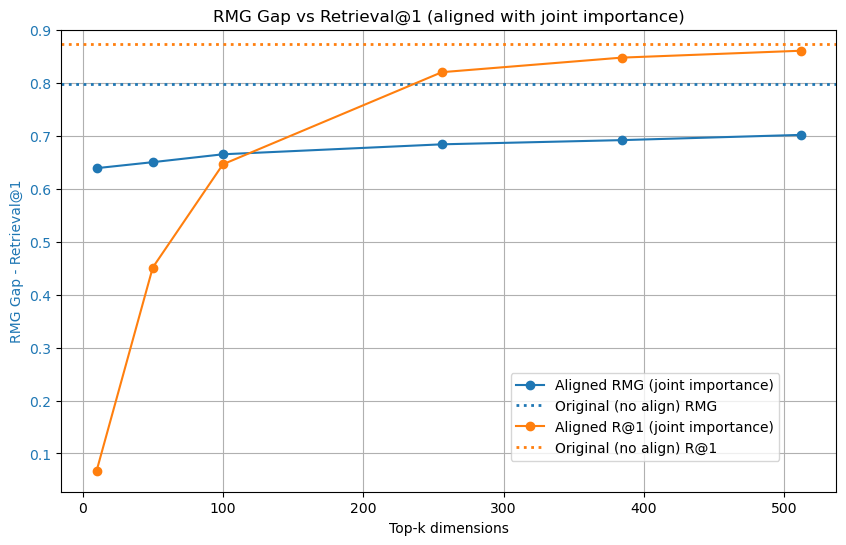

In [230]:
# Unique graph with 2 lines, one for RMG and one for Recall@1 against k (normalize the values to [0,1] for better comparison)
fig, ax1 = plt.subplots(figsize=(10, 6))
color_rmg = "tab:blue"
color_r1 = "tab:orange"
ax1.set_xlabel("Top-k dimensions")
ax1.set_ylabel("RMG Gap - Retrieval@1", color=color_rmg)
ax1.plot(
    k_sweep,
    [k_sweep_result_joint[k]["gaps_aligned"]["RMG"] for k in k_sweep],
    marker="o",
    label="Aligned RMG (joint importance)",
    color=color_rmg
)
ax1.axhline(
    avg_gaps_original["RMG"],
    color=color_rmg,
    linestyle=":",
    linewidth=2,
    label="Original (no align) RMG",
)

ax1.plot(
    k_sweep,
    [k_sweep_result_joint[k]["retrieval_aligned"][1] for k in k_sweep],
    marker="o",
    label="Aligned R@1 (joint importance)",
    color=color_r1
)
ax1.axhline(
    avg_retrieval_original[1],
    color=color_r1, 
    linestyle=":",
    linewidth=2,
    label="Original (no align) R@1"
)
ax1.tick_params(axis="y", labelcolor=color_rmg)
# legend
fig.legend(loc="lower right", bbox_to_anchor=(0.85, 0.15))
plt.title("RMG Gap vs Retrieval@1 (aligned with joint importance)")
plt.grid(True)
plt.show()

#### From top dim by semantic importance remove the ones with higher gaps


In [115]:
# Compute the correct overlapping dimensions between the top-k important dimensions and the top-k gap dimensions
k_sweep = [10, 50, 100, 256, 384]
overlaps = {
    10: [],
    50: [],
    100: [],
    256: [],
    384: []
}
for k in k_sweep:
    top_k_dims_joint = analysis["top"]["impJ"][:k]  # top-k by joint importance
    top_k_dims_gap = analysis["top"]["gap"][:k]     # top-k by gap
    overlap = set(top_k_dims_joint).intersection(set(top_k_dims_gap))
    overlaps[k] = list(overlap)


In [117]:
print("Overlaps between top-k important dimensions and top-k gap dimensions:")
for k in k_sweep:
    print(f"Top-{k}: {len(overlaps[k])} ({len(overlaps[k])/k*100:.1f}%)")

Overlaps between top-k important dimensions and top-k gap dimensions:
Top-10: 0 (0.0%)
Top-50: 15 (30.0%)
Top-100: 42 (42.0%)
Top-256: 145 (56.6%)
Top-384: 297 (77.3%)


In [123]:
# For each k, we run retrieval with 2 tests: one using only the overlapping dimensions, and one using only the non-overlapping dimensions. We compare the retrieval performance in these two cases to see if the overlapping dimensions are indeed more important for retrieval.
retrieval_overlap = dict()
retrieval_non_overlap = dict()
for k in k_sweep:
    overlap_dims = overlaps[k]
    non_overlap_dims = list(set(analysis["top"]["gap"][:k]) - set(overlap_dims))
    
    print(f"\nRetrieval using only overlapping dimensions (k={k}, overlap={len(overlap_dims)})")
    retrieval_overlap[k] = retrieval_with_top_k_dims_semantic_importance(test_loader, overlap_dims, sub_model, device="cpu")
    
    print(f"\nRetrieval using only non-overlapping dimensions (k={k}, non-overlap={len(non_overlap_dims)})")
    retrieval_non_overlap[k] = retrieval_with_top_k_dims_semantic_importance(test_loader, non_overlap_dims, sub_model, device="cpu")


Retrieval using only overlapping dimensions (k=10, overlap=0)


Retrieval with top-0 dims: 100%|██████████| 25/25 [00:00<00:00, 177.46it/s]



Retrieval using only non-overlapping dimensions (k=10, non-overlap=10)


Retrieval with top-10 dims: 100%|██████████| 25/25 [00:01<00:00, 13.54it/s]



Retrieval using only overlapping dimensions (k=50, overlap=15)


...

Retrieval with top-111 dims: 100%|██████████| 25/25 [00:02<00:00, 11.38it/s]



Retrieval using only overlapping dimensions (k=384, overlap=297)


Retrieval with top-297 dims: 100%|██████████| 25/25 [00:04<00:00,  5.61it/s]



Retrieval using only non-overlapping dimensions (k=384, non-overlap=87)


Retrieval with top-87 dims: 100%|██████████| 25/25 [00:02<00:00, 12.29it/s]


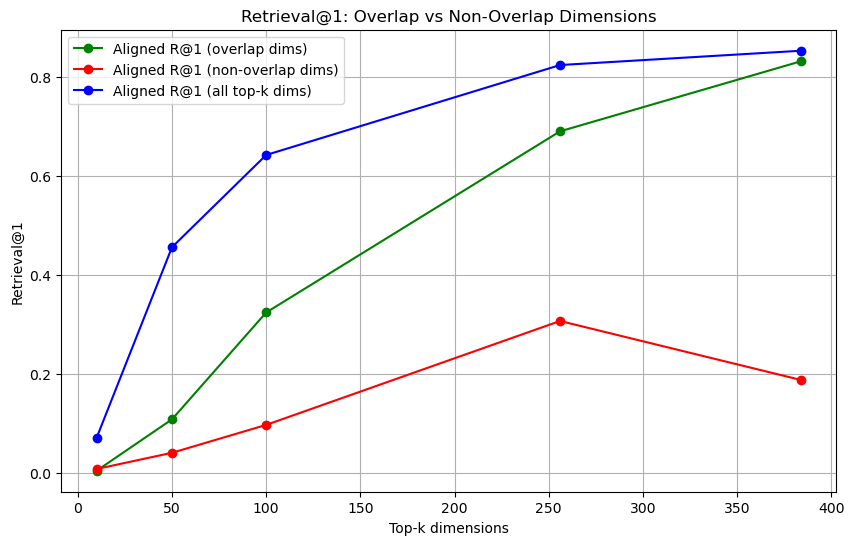

In [126]:
# plot retrieval@1 for overlap vs non-overlap
# report also the retrieval@1 using the entire top-k dimensions (from previous results) for reference
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    k_sweep,
    [retrieval_overlap[k]["retrieval_aligned"][1] for k in k_sweep],
    marker="o",
    label="Aligned R@1 (overlap dims)",
    color="green"
)
ax.plot(
    k_sweep,
    [retrieval_non_overlap[k]["retrieval_aligned"][1] for k in k_sweep],
    marker="o",
    label="Aligned R@1 (non-overlap dims)",
    color="red"
)
ax.plot(
    k_sweep,
    [k_sweep_result_joint[k]["retrieval_aligned"][1] for k in k_sweep],
    marker="o",
    label="Aligned R@1 (all top-k dims)",
    color="blue"
)
ax.set_xlabel("Top-k dimensions")
ax.set_ylabel("Retrieval@1")
ax.set_title("Retrieval@1: Overlap vs Non-Overlap Dimensions")
ax.legend()
ax.grid(True)
plt.show()



From here we see that we actually need all the top k dimension (importance subspace) even if they have high gap. Removing this from the top k doesn't benefit retrieval.
Using only same, does not benefit (as expected).

#### Plot using top dims by gap


In [127]:
def retrieval_with_top_k_dims_by_gap(test_loader, top_k_dims, subspace_alignment_model, device="cpu"):
    r_orig = {1: [], 5: [], 10: []}
    r_al   = {1: [], 5: [], 10: []}
    gaps = ['RMG', 'L2M', 'L2I']
    gaps_orig = {g: [] for g in gaps}
    gaps_al = {g: [] for g in gaps}

    with torch.no_grad():
        for text_b, vis_b in tqdm(test_loader, desc=f"Retrieval with top-{len(top_k_dims)} dims by gap"):
            X = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            Y = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()

            # original retrieval on top-k dims
            r_orig[1].append(retrieval(X[:, top_k_dims], Y[:, top_k_dims], top_k=1))
            r_orig[5].append(retrieval(X[:, top_k_dims], Y[:, top_k_dims], top_k=5))
            r_orig[10].append(retrieval(X[:, top_k_dims], Y[:, top_k_dims], top_k=10))

            # aligned vision -> text-space on top-k dims
            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, subspace_alignment_model, renorm=True)
            r_al[1].append(retrieval(Xn[:, top_k_dims], Yaln[:, top_k_dims], top_k=1))
            r_al[5].append(retrieval(Xn[:, top_k_dims], Yaln[:, top_k_dims], top_k=5))
            r_al[10].append(retrieval(Xn[:, top_k_dims], Yaln[:, top_k_dims], top_k=10))
            
            # compute gaps on top-k dims
            for g in gaps:
                go = compute_gap(g, X[:, top_k_dims], Y[:, top_k_dims], iterations=None)
                gaps_orig[g].append(go["text_vision"] if isinstance(go, dict) and "text_vision" in go else go)
                
                ga = compute_gap(g, Xn[:, top_k_dims], Yaln[:, top_k_dims], iterations=None)
                gaps_al[g].append(ga["text_vision"] if isinstance(ga, dict) and "text_vision" in ga else ga)
                
            

    # print(f"\n=== Retrieval with Top-{len(top_k_dims)} Dims by Gap ({len(top_k_dims)} most important) ===")
    # print(f"Retrieval@1  orig: {np.mean(r_orig[1]):.4f} | aligned: {np.mean(r_al[1]):.4f}")
    # print(f"Retrieval@5  orig: {np.mean(r_orig[5]):.4f} | aligned: {np.mean(r_al[5]):.4f}")
    # print(f"Retrieval@10 orig: {np.mean(r_orig[10]):.4f} | aligned: {np.mean(r_al[10]):.4f}")
    # print("Gaps")
    # for g in gaps:
    #     print(f"{g}  orig: {np.mean(gaps_orig[g]):.4f} | aligned: {np.mean(gaps_al[g]):.4f}")
        
    return  {
        "retrieval_orig": {k: float(np.mean(v)) for k,v in r_orig.items()},
        "retrieval_aligned": {k: float(np.mean(v)) for k,v in r_al.items()},
        "gaps_orig": {g: float(np.mean(v)) for g,v in gaps_orig.items()},
        "gaps_aligned": {g: float(np.mean(v)) for g,v in gaps_al.items()}
    }

#### Eval retrieval using the top dim by gap

Retrieval with top-512 dims by gap: 100%|██████████| 25/25 [00:06<00:00,  3.57it/s]


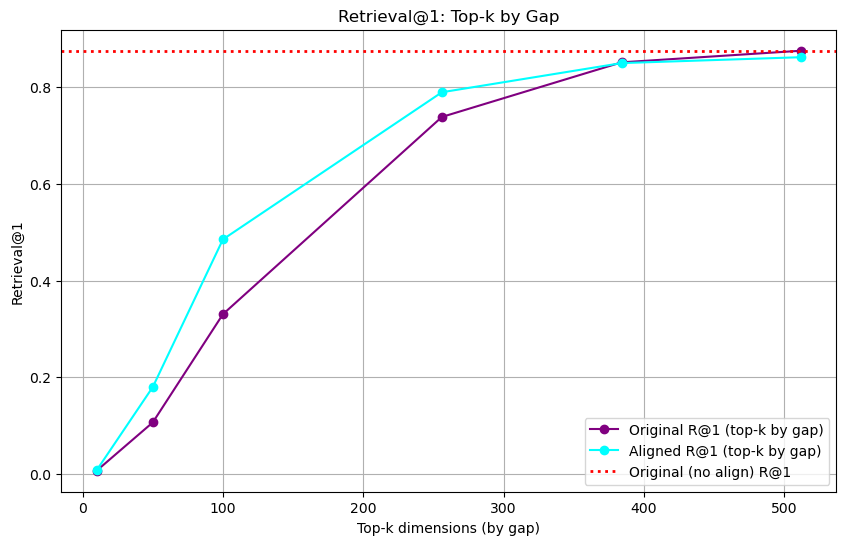

In [231]:
k_sweep = [10, 50, 100, 256, 384, 512]
k_sweep_result_gap = dict()
for k in k_sweep:
    top_k_dims_gap = analysis["top"]["gap"][:k]  # top-k by gap
    k_sweep_result_gap[k] = retrieval_with_top_k_dims_by_gap(test_loader, top_k_dims_gap, sub_model, device="cpu")

# Plot retrieval@1 for top-k by gap
fig, ax = plt.subplots(figsize=(10, 6))
retrieval_orig = [k_sweep_result_gap[k]["retrieval_orig"][1] for k in k_sweep]
retrieval_aligned = [k_sweep_result_gap[k]["retrieval_aligned"][1] for k in k_sweep]
ax.plot(
    k_sweep,
    retrieval_orig,
    marker="o",
    label="Original R@1 (top-k by gap)",
    color="purple"
)
ax.plot(
    k_sweep,
    retrieval_aligned,
    marker="o",
    label="Aligned R@1 (top-k by gap)",
    color="cyan"
)
ax.axhline(
    avg_retrieval_original[1],
    color="red",
    linestyle=":",
    linewidth=2,
    label="Original (no align) R@1"
)
ax.set_xlabel("Top-k dimensions (by gap)")
ax.set_ylabel("Retrieval@1")
ax.set_title("Retrieval@1: Top-k by Gap")
ax.legend()
ax.grid(True)
plt.show()  

#### Eval retrieval removing top k dimensions by gap


In [232]:
k_sweep = [10, 50, 100, 256, 384]

In [233]:
# Retrieval using the dimensions (aligned and original) removing the top-k gap dimensions with k=10, 50, 100, 256, 384, 512
retrieval_removed_gap = dict()
for k in k_sweep:
    top_k_dims_gap = analysis["top"]["gap"][:k]  # top-k by gap
    remaining_dims = list(set(range(512)) - set(top_k_dims_gap))
    retrieval_removed_gap[k] = retrieval_with_top_k_dims_by_gap(test_loader, remaining_dims, sub_model, device="cpu")

Retrieval with top-502 dims by gap:   0%|          | 0/25 [00:00<?, ?it/s]

Retrieval with top-128 dims by gap: 100%|██████████| 25/25 [00:02<00:00, 11.24it/s]


In [234]:
# count of remaining dimensions after removing top-k gap dimensions
used_dims_count = {k: len(set(range(512)) - set(analysis["top"]["gap"][:k])) for k in k_sweep}
print("Remaining dimensions after removing top-k gap dimensions:")
for k in k_sweep:
    print(f"Removed top-{k} gap dims: Remaining dims = {used_dims_count[k]}")

Remaining dimensions after removing top-k gap dimensions:
Removed top-10 gap dims: Remaining dims = 502
Removed top-50 gap dims: Remaining dims = 462
Removed top-100 gap dims: Remaining dims = 412
Removed top-256 gap dims: Remaining dims = 256
Removed top-384 gap dims: Remaining dims = 128


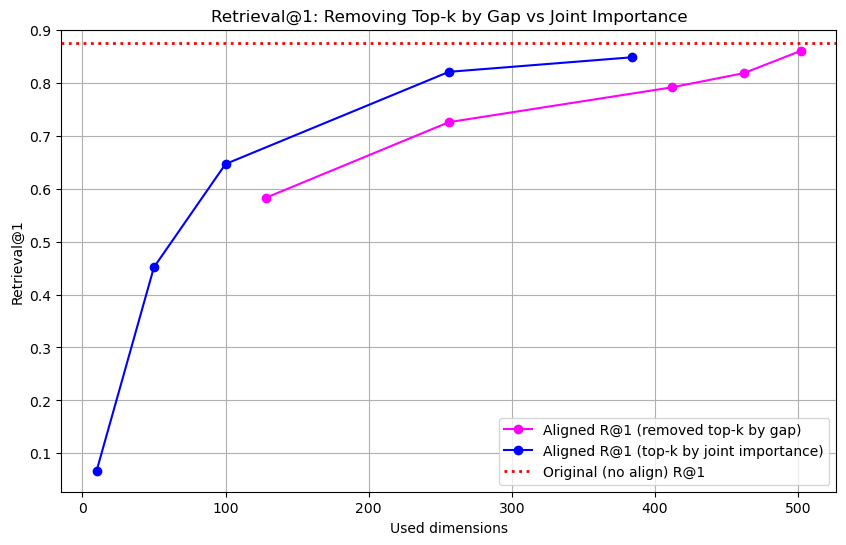

In [235]:
# Plot retrieval@1 for removed top-k by gap (x axis is the number of remaining dimensions), plot also the retrieval@1 using the top-k by joint importance for reference (x axis is k), and the original retrieval@1 with all dimensions for reference (horizontal line)
fig, ax = plt.subplots(figsize=(10, 6))
retrieval_removed = [retrieval_removed_gap[k]["retrieval_aligned"][1] for k in k_sweep]
retrieval_joint = [k_sweep_result_joint[k]["retrieval_aligned"][1] for k in k_sweep]
ax.plot(
    [used_dims_count[k] for k in k_sweep],
    retrieval_removed,
    marker="o",
    label="Aligned R@1 (removed top-k by gap)",
    color="magenta"
)
ax.plot(
    k_sweep,
    retrieval_joint,
    marker="o",
    label="Aligned R@1 (top-k by joint importance)",
    color="blue"
)
ax.axhline(
    avg_retrieval_original[1],
    color="red",
    linestyle=":",
    linewidth=2,
    label="Original (no align) R@1"
)
ax.set_xlabel("Used dimensions")
ax.set_ylabel("Retrieval@1")
ax.set_title("Retrieval@1: Removing Top-k by Gap vs Joint Importance")
ax.legend()
ax.grid(True)
plt.show()

In [ ]:
### Now let's see how the gap behaves on the aligned space when we remove the top-k gap dimensions. 
# We expect that if we remove the dimensions that contribute most to the gap, the gap should decrease significantly in the aligned space, and this should correlate with a decrease in retrieval performance.

gaps = ['RMG', 'L2M', 'L2I']
gap_values_removed = {
    512-k: {f"{g}": [] for g in gaps} for k in k_sweep
}
# Compute the gap values on the aligned space after removing top-k gap dimensions
for k in k_sweep:
    top_k_dims_gap = analysis["top"]["gap"][:k]  # top-k by gap
    remaining_dims = list(set(range(512)) - set(top_k_dims_gap))
    
    with torch.no_grad():
        for text_b, vis_b in tqdm(test_loader, desc=f"Computing gaps with top-{k} gap dims removed"):
            X = F.normalize(text_b.to("cpu"), dim=-1).numpy()
            Y = F.normalize(vis_b.to("cpu"),  dim=-1).numpy()

            # aligned vision -> text-space on remaining dims
            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, sub_model, renorm=True)
            for g in gaps:
                gap_values_removed[512-k][g].append(compute_gap(g, Xn[:, remaining_dims], Yaln[:, remaining_dims], iterations=None)["text_vision"])
            
    
    # compute mean gap values for this k
    for g in gaps:
        gap_values_removed[512-k][g] = float(np.mean(gap_values_removed[512-k][g]))    

Computing gaps with top-384 gap dims removed: 100%|██████████| 25/25 [00:01<00:00, 21.16it/s]


In [276]:
# Recompute and store the gap values on the aligned space using the sweep dimensions by joint importance for reference
gaps_by_joint = {k: {f"{g}": [] for g in gaps} for k in k_sweep}

for d in [10, 50, 100, 256, 384]:
    sub_model = fit_subspace_alignment(train_loader, n_fit=10_000, d_sub=d, device="cpu")
    top_k_dim_joint = analysis["top"]["impJ"][:d]  # top-k by joint importance
    with torch.no_grad():
        for text_b, vis_b in tqdm(test_loader, desc=f"Computing gaps for top-{d} by joint importance"):
            X = F.normalize(text_b.to("cpu"), dim=-1).numpy()
            Y = F.normalize(vis_b.to("cpu"),  dim=-1).numpy()

            # aligned vision -> text-space on top-k by joint importance
            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, sub_model, renorm=True)
            for g in gaps:
                gaps_by_joint[d][g].append(compute_gap(g, Xn[:, top_k_dim_joint], Yaln[:, top_k_dim_joint], iterations=None)["text_vision"])
        
    # compute mean gap values for this d
    for g in gaps:
        gaps_by_joint[d][g] = float(np.mean(gaps_by_joint[d][g]))   
        

Computing gaps for top-384 by joint importance: 100%|██████████| 25/25 [00:02<00:00,  9.65it/s]


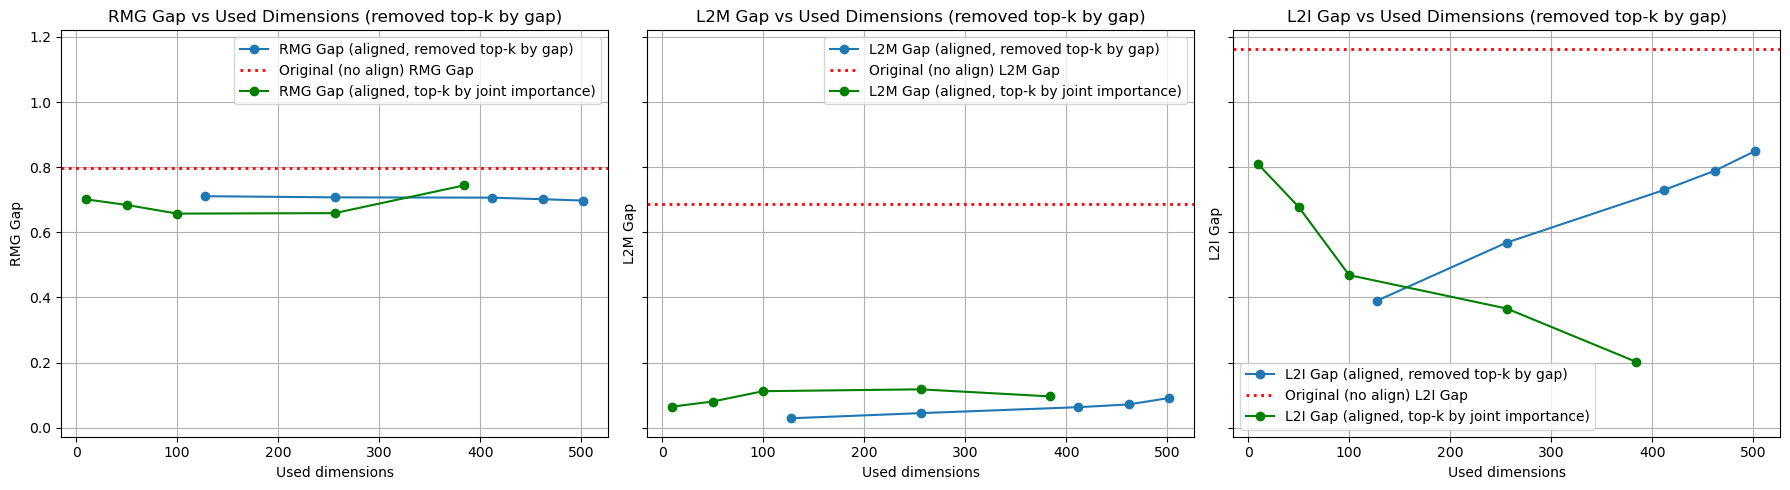

In [280]:
used_dim = list(gap_values_removed.keys())
used_dim.sort()
# show the gap for the top-k dim by joint importance for reference

# Plot the gap values vs used dimensions after removing top-k gap dimensions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
for ax, g in zip(axes, gaps):
    gap_vals = [gap_values_removed[ud][g] for ud in used_dim]
    ax.plot(
        used_dim,
        gap_vals,
        marker="o",
        label=f"{g} Gap (aligned, removed top-k by gap)"
    )
    ax.axhline(
        avg_gaps_original[g],
        color="red",
        linestyle=":",
        linewidth=2,
        label=f"Original (no align) {g} Gap"
    )
    # plot also the gap values for the top-k by joint importance for reference
    joint_gap_vals = [gaps_by_joint[512-ud][g] for ud in used_dim]
    ax.plot(
        list(gaps_by_joint.keys()),
        joint_gap_vals,
        marker="o",
        label=f"{g} Gap (aligned, top-k by joint importance)",
        color="green"
    )
    ax.set_title(f"{g} Gap vs Used Dimensions (removed top-k by gap)")
    ax.set_xlabel("Used dimensions")
    ax.set_ylabel(f"{g} Gap")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()  


#### Top dim by gap vs top dim by semantic importance

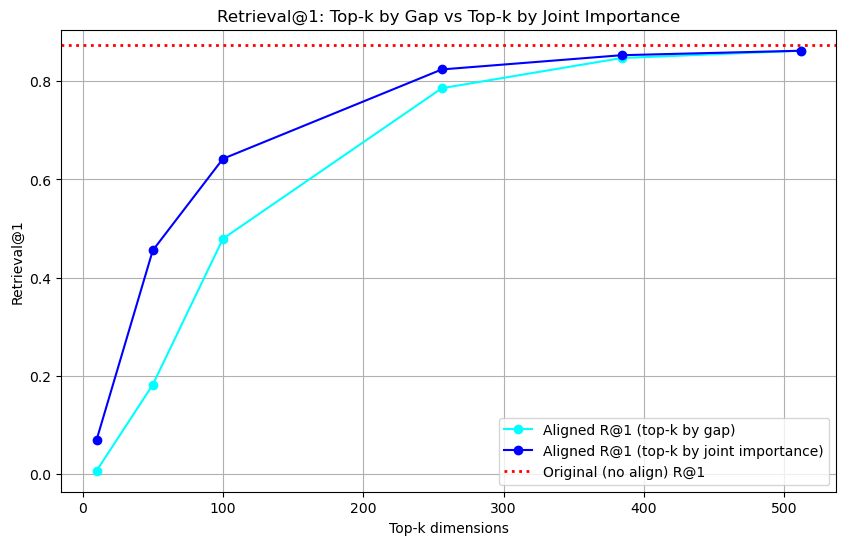

In [129]:
# Retrieval@1 for top-k by gap vs top-k by importance (joint)
fig, ax = plt.subplots(figsize=(10, 6))
retrieval_gap = [k_sweep_result_gap[k]["retrieval_aligned"][1] for k in k_sweep]
retrieval_joint = [k_sweep_result_joint[k]["retrieval_aligned"][1] for k in k_sweep]
ax.plot(
    k_sweep,
    retrieval_gap,
    marker="o",
    label="Aligned R@1 (top-k by gap)",
    color="cyan"
)
ax.plot(
    k_sweep,
    retrieval_joint,
    marker="o",
    label="Aligned R@1 (top-k by joint importance)",
    color="blue"
)
ax.axhline(
    avg_retrieval_original[1],
    color="red",
    linestyle=":",
    linewidth=2,
    label="Original (no align) R@1"
)
ax.set_xlabel("Top-k dimensions")
ax.set_ylabel("Retrieval@1")
ax.set_title("Retrieval@1: Top-k by Gap vs Top-k by Joint Importance")
ax.legend()
ax.grid(True)
plt.show()

In [ ]:
# Classificazione / cluestering

## Orthogonal procrustes
Qui rifacciamo gli stessi test del Procrustes generico, ma imponendo che la trasformazione sia **ortogonale** (rotazione/riflessione): $T^\top T = I$. Questo corrisponde alla versione classica *Orthogonal Procrustes* e limita la mappa a trasformazioni isometriche (a parte il preprocessing `translate/scale`).

In [2]:
import numpy as np
from procrustes.orthogonal import orthogonal

In [17]:

def fit_orthogonal_procrustes_on_10k(train_loader, n_fit=10_000, translate=True, scale=True, device="cpu"):
    """Fit Orthogonal Procrustes su 10k campioni usando il package `procrustes`.

    Ritorna un mapping con la stessa struttura di `fit_procrustes_on_10k`,
    così puoi riusare `eval_test_pre_post` senza cambiare nulla.
    """
    X_fit, Y_fit = collect_embeddings(train_loader, max_samples=n_fit, device=device)

    # Orthogonal Procrustes: minimizza ||A T - B||_F con T ortogonale
    res = orthogonal(X_fit, Y_fit, pad=True, translate=translate, scale=scale, lapack_driver="gesvd")
    T = res.t
    fit_err = float(res.error) if not hasattr(res.error, "item") else float(res.error.item())

    # preprocessing stats coerenti con translate/scale (come per generic)
    mu_X = X_fit.mean(axis=0, keepdims=True)
    mu_Y = Y_fit.mean(axis=0, keepdims=True)
    eps = 1e-12
    s_X = np.linalg.norm(X_fit - mu_X, ord="fro") + eps
    s_Y = np.linalg.norm(Y_fit - mu_Y, ord="fro") + eps

    return {"T": T, "mu_X": mu_X, "mu_Y": mu_Y, "s_X": s_X, "s_Y": s_Y, "fit_error": fit_err}


Eval test pre/post: 100%|██████████| 25/25 [00:00<00:00, 206.38it/s]



=== TEST RESULTS ===
Procrustes fit_error on 10k: 1.048972
Retrieval@1  orig: 0.8746 | aligned: 0.8166
Retrieval@5  orig: 0.9742 | aligned: 0.9551
Retrieval@10 orig: 0.9877 | aligned: 0.9771
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924092292786, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.6938672873763766, 'L2M': 0.01859080232679844, 'L2I': 1.0586942434310913}


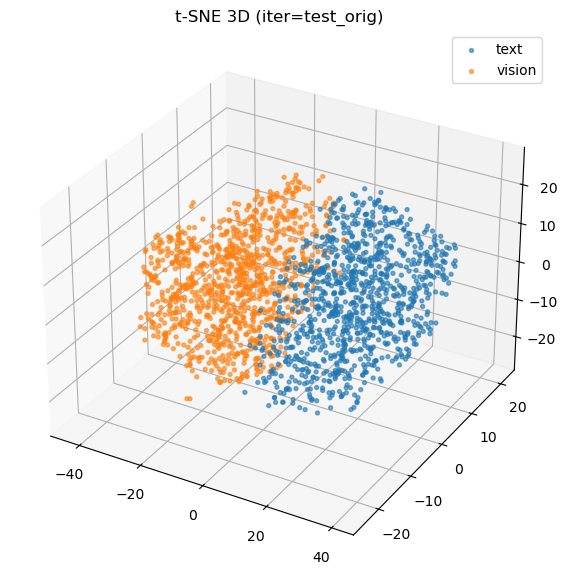

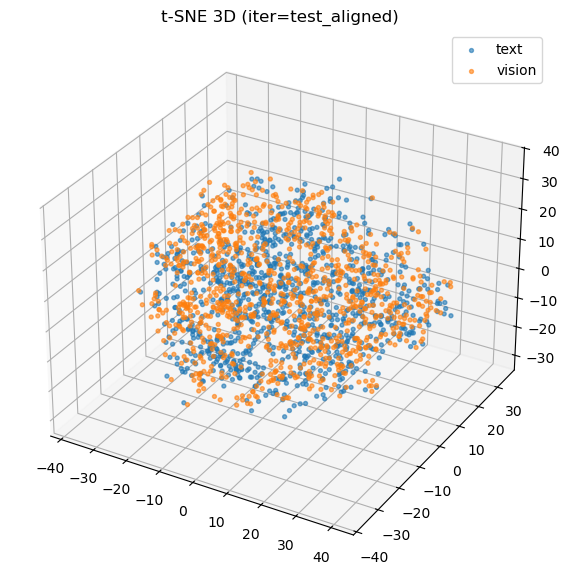

{'retrieval_orig': {1: 0.8745855331420899,
  5: 0.9741857385635376,
  10: 0.987749412059784},
 'retrieval_aligned': {1: 0.816645393371582,
  5: 0.9550916957855224,
  10: 0.9770928692817687},
 'gaps_orig': {'RMG': 0.7976485819287372,
  'L2M': 0.6844924092292786,
  'L2I': 1.163695216178894},
 'gaps_aligned': {'RMG': 0.6938672873763766,
  'L2M': 0.01859080232679844,
  'L2I': 1.0586942434310913}}

In [18]:
# Fit + evaluation (pre/post) con Procrustes ORTOGONALE
train_loader, test_loader = make_loaders(precomputed_dir, split_name="flickr30k", batch_size=256, seed=0, num_workers=0)

mapping_ortho_10k = fit_orthogonal_procrustes_on_10k(train_loader, n_fit=10_000, translate=True, scale=True, device="cpu")
test_stats_ortho = eval_test_pre_post(test_loader, mapping_ortho_10k, device="cpu")

test_stats_ortho

#### Note di lettura (cosa aspettarsi)

- Se l’ipotesi “isometria globale” tra le due modalità regge, l’**ortogonale** dovrebbe performare **quasi come** il Procrustes generico.
- Se invece il generico migliora molto di più, significa che parte del “gap” viene chiusa grazie a componenti **non isometriche** (scaling anisotropo / shear) che l’ortogonale non può usare.
- Con `translate=True, scale=True` stai già centrando e normalizzando Frobenius su train (come nel generic), quindi le differenze che rimangono sono principalmente dovute al **vincolo ortogonale su T**.


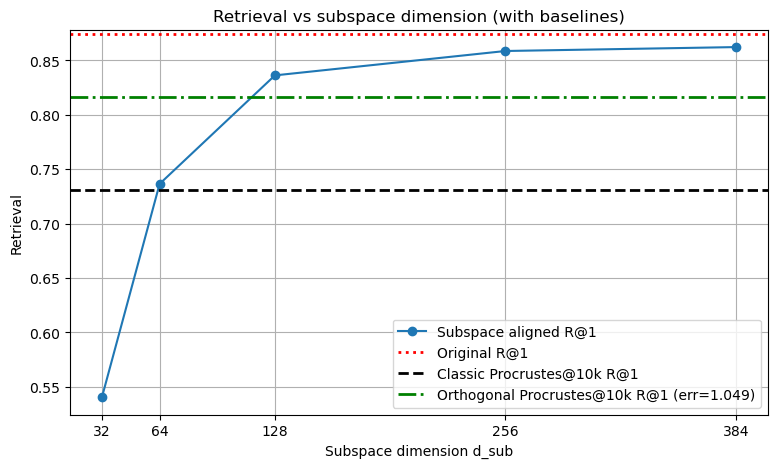

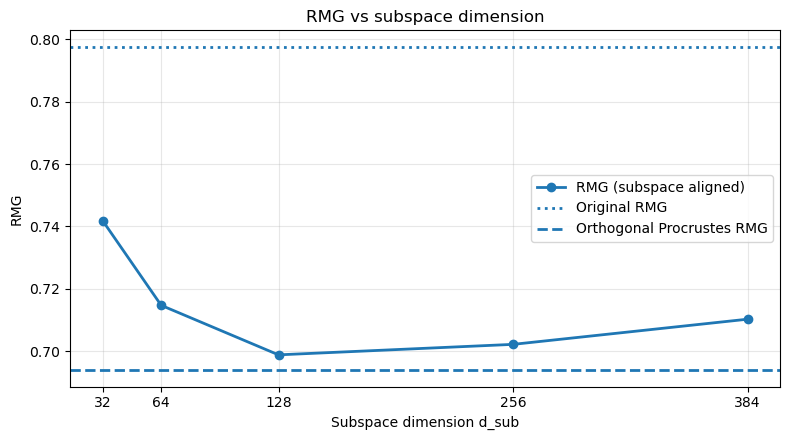

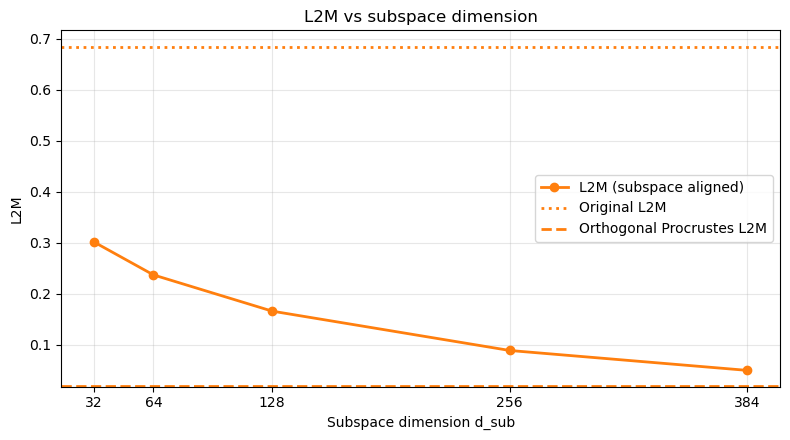

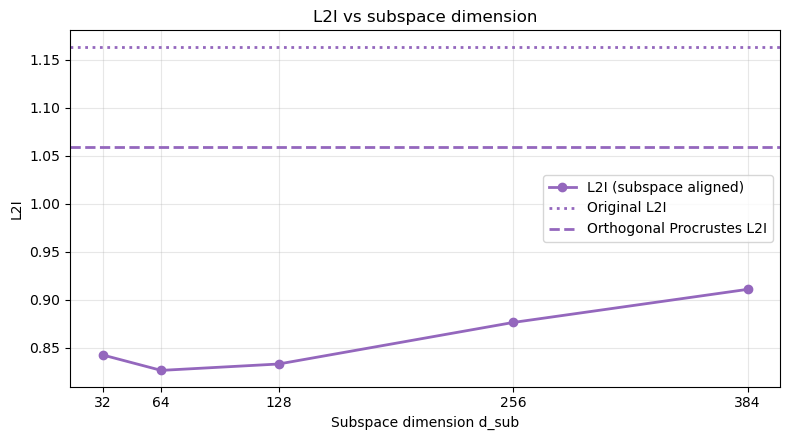

In [29]:
# --- Subspace sweep results (aligned) ---
results = [
    {"d_sub": 32,  "retrieval@1": 0.5406, "retrieval@5": 0.8407, "retrieval@10": 0.9180,
     "RMG": 0.7418968617387169, "L2M": 0.3014943301677704, "L2I": 0.8425172567367554},
    {"d_sub": 64,  "retrieval@1": 0.7365, "retrieval@5": 0.9356, "retrieval@10": 0.9671,
     "RMG": 0.7147150678988811, "L2M": 0.23713606595993042, "L2I": 0.8264103531837463},
    {"d_sub": 128, "retrieval@1": 0.8362, "retrieval@5": 0.9629, "retrieval@10": 0.9834,
     "RMG": 0.6988464308853876, "L2M": 0.16616225242614746, "L2I": 0.8330492377281189},
    {"d_sub": 256, "retrieval@1": 0.8586, "retrieval@5": 0.9715, "retrieval@10": 0.9849,
     "RMG": 0.7022089214672783, "L2M": 0.0890965685248375, "L2I": 0.8763177394866943},
    {"d_sub": 384, "retrieval@1": 0.8622, "retrieval@5": 0.9715, "retrieval@10": 0.9862,
     "RMG": 0.7102776515662346, "L2M": 0.05012039095163345, "L2I": 0.9108297228813171},
]

# --- Baselines ---
original_baseline = {
    "retrieval@1": 0.8746, "retrieval@5": 0.9742, "retrieval@10": 0.9877,
    "RMG": 0.7976485819287372, "L2M": 0.6844924092292786, "L2I": 1.163695216178894
}

classic_procrustes = {
    "retrieval@1": 0.7309, "retrieval@5": 0.9254, "retrieval@10": 0.9647,
    # (se non hai gap per classic, lasciali None oppure toglili)
    "RMG": None, "L2M": None, "L2I": None
}

orthogonal_procrustes = {
    "fit_error": 1.048972,
    "retrieval@1": 0.8166, "retrieval@5": 0.9551, "retrieval@10": 0.9771,
    "RMG": 0.6938672873763766, "L2M": 0.01859080232679844, "L2I": 1.0586942434310913
}

# ---- sort sweep by d_sub
results = sorted(results, key=lambda x: x["d_sub"])
d = np.array([r["d_sub"] for r in results])

# -----------------------------
# Plot 1: Retrieval@k vs d_sub
#   - original baseline in RED (dotted)
#   - classic procrustes baseline in BLACK (dashed)
#   - orthogonal procrustes baseline in GREEN (dashdot)
# -----------------------------
plt.figure(figsize=(9, 5))

# Sweep curves
plt.plot(d, [r["retrieval@1"] for r in results], marker='o', label="Subspace aligned R@1")
# plt.plot(d, [r["retrieval@5"] for r in results], marker='o', label="Subspace aligned R@5")
# plt.plot(d, [r["retrieval@10"] for r in results], marker='o', label="Subspace aligned R@10")

# Baselines
plt.axhline(original_baseline["retrieval@1"], color="red", linestyle=":", linewidth=2, label="Original R@1")
# plt.axhline(original_baseline["retrieval@5"], color="red", linestyle=":", linewidth=2, label="Original R@5")
# plt.axhline(original_baseline["retrieval@10"], color="red", linestyle=":", linewidth=2, label="Original R@10")

plt.axhline(classic_procrustes["retrieval@1"], color="black", linestyle="--", linewidth=2, label="Classic Procrustes@10k R@1")
# plt.axhline(classic_procrustes["retrieval@5"], color="black", linestyle="--", linewidth=2, label="Classic Procrustes@10k R@5")
# plt.axhline(classic_procrustes["retrieval@10"], color="black", linestyle="--", linewidth=2, label="Classic Procrustes@10k R@10")

plt.axhline(orthogonal_procrustes["retrieval@1"], color="green", linestyle="-.", linewidth=2,
            label=f"Orthogonal Procrustes@10k R@1 (err={orthogonal_procrustes['fit_error']:.3f})")
# plt.axhline(orthogonal_procrustes["retrieval@5"], color="green", linestyle="-.", linewidth=2,
#             label="Orthogonal Procrustes@10k R@5")
# plt.axhline(orthogonal_procrustes["retrieval@10"], color="green", linestyle="-.", linewidth=2,
#             label="Orthogonal Procrustes@10k R@10")

plt.xlabel("Subspace dimension d_sub")
plt.ylabel("Retrieval")
plt.title("Retrieval vs subspace dimension (with baselines)")
plt.xticks(d)
plt.grid(True)
plt.legend()
plt.show()


# -----------------------------
# Plot 2: One graph per gap metric
#   + baselines (original + orthogonal + classic if available)
# -----------------------------
for metric in ["RMG", "L2M", "L2I"]:
    plt.figure(figsize=(8, 4.5))

    # Subspace sweep
    plt.plot(
        d,
        [r[metric] for r in results],
        marker="o",
        linestyle="-",
        color=metric_colors.get(metric, "tab:blue"),
        linewidth=2,
        label=f"{metric} (subspace aligned)"
    )

    # Original baseline
    plt.axhline(
        original_baseline[metric],
        color=metric_colors.get(metric, "tab:blue"),
        linestyle=":",
        linewidth=2,
        label=f"Original {metric}"
    )

    # Orthogonal baseline
    plt.axhline(
        orthogonal_procrustes[metric],
        color=metric_colors.get(metric, "tab:blue"),
        linestyle="--",
        linewidth=2,
        label=f"Orthogonal Procrustes {metric}"
    )

    # Classic baseline (only if present)
    if classic_procrustes.get(metric) is not None:
        plt.axhline(
            classic_procrustes[metric],
            color=metric_colors.get(metric, "tab:blue"),
            linestyle="-.",
            linewidth=2,
            label=f"Classic Procrustes {metric}"
        )

    plt.xlabel("Subspace dimension d_sub")
    plt.ylabel(metric)
    plt.title(f"{metric} vs subspace dimension")
    plt.xticks(d)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()